# Tối ưu hoá log-loss — Santander Product Recommendation

Bài toán: hồi quy logistic dự đoán khách hàng **mua thêm** sản phẩm nào ở tháng $t$.

$$F(w)=\underbrace{\frac1n\sum_{i=1}^n\Big[\log\big(1+e^{z_i}\big)-y_iz_i\Big]}_{\text{log-loss}}
+\ \text{phần hiệu chỉnh},\qquad z=Xw$$

File này chỉ làm hai việc: **dựng ma trận đặc trưng** và **định nghĩa hai hàm mục tiêu**
(Ridge và Lasso). Các thuật toán tối ưu viết tiếp ở dưới.

In [1]:
import numpy as np
import pandas as pd

## 1. Đặc trưng — kiểu lời giải top Kaggle (160 đặc trưng + cột chặn)

Mỗi mẫu là một **tháng $t$** của một khách hàng, kèm **5 tháng trước đó** $(t-1,\dots,t-5)$:
đặc trưng lấy từ hồ sơ khách hàng và lịch sử sở hữu sản phẩm, nhãn là *"tháng $t$ có sản phẩm
mà tháng $t-1$ chưa có"*:

$$y_i=\mathbb{1}\big[\text{có ở }t\big]\cdot\mathbb{1}\big[\text{chưa có ở }t-1\big]$$

Bộ đặc trưng dựng theo hướng của các lời giải đứng đầu cuộc thi (hạng 1 idle_speculation,
hạng 2 Tom Van de Wiele): tín hiệu mạnh nhất là **lịch sử sở hữu sản phẩm qua nhiều tháng**,
không chỉ tháng liền trước.

| Nhóm | Số cột | Cột | Cách tính |
|---|---|---|---|
| chặn | 1 | `intercept` | cột toàn số 1, **không bị phạt** |
| số | 6 | `age`, `antiguedad`, `renta`, `ind_nuevo`, `ind_actividad_cliente`, `alta_year` | cắt ngưỡng cho hết ngoại lai; `renta` lấy $\log(1+x)$; `alta_year` = năm trong `fecha_alta`; thiếu thì điền trung vị |
| nhị phân | 7 | `sexo_V`, `seg_part`, `seg_univ`, `tiprel_I`, `kenh_KHE`, `kenh_KAT`, `kenh_KFC` | one-hot bỏ mức tham chiếu; kênh chỉ giữ 3 kênh phổ biến nhất |
| sở hữu $t-1$ | 24 | `ind_*_lag` | có sản phẩm đó ở tháng $t-1$ hay chưa (0/1) |
| sở hữu $t-2..t-5$ | 96 | `ind_*_lag2` … `ind_*_lag5` | như trên, lùi 2–5 tháng; khách chưa mở tài khoản ở tháng đó thì tính là chưa có |
| thời gian | 24 | `ind_*_thang` | số tháng kể từ lần gần nhất có sản phẩm đó (1–5; **6** = không có trong cả 5 tháng) |
| tổng hợp | 3 | `so_sp`, `doi_seg`, `doi_hd` | số sản phẩm đang có ở $t-1$; phân khúc / trạng thái hoạt động có đổi so với $t-1$ không |

Mọi cột đưa về cùng thang đo $\;(x-\mu)/\sigma$ (dùng $\mu,\sigma$ **của tập train**) để mọi
toạ độ có độ cong tương đương — nếu không, `renta` cỡ vạn còn cờ 0/1 cỡ 1 thì gradient descent
sẽ zig-zag rất lâu.

**Cỡ mẫu.** Giữ nguyên cách lấy mẫu cũ: **1/12 số khách** (lọc theo mã khách, cùng một tập khách
xuyên suốt mọi tháng), 13 tháng 2015-01 → 2016-01, validation là tháng 2016-01. Vì cần đủ 5
tháng lịch sử nên tháng mục tiêu của tập train bắt đầu từ 2015-06 (7 tháng thay vì 11) — ít
dòng hơn bản cũ.

In [2]:
SP = ["ind_ahor_fin_ult1", "ind_aval_fin_ult1", "ind_cco_fin_ult1", "ind_cder_fin_ult1",
      "ind_cno_fin_ult1", "ind_ctju_fin_ult1", "ind_ctma_fin_ult1", "ind_ctop_fin_ult1",
      "ind_ctpp_fin_ult1", "ind_deco_fin_ult1", "ind_deme_fin_ult1", "ind_dela_fin_ult1",
      "ind_ecue_fin_ult1", "ind_fond_fin_ult1", "ind_hip_fin_ult1", "ind_plan_fin_ult1",
      "ind_pres_fin_ult1", "ind_reca_fin_ult1", "ind_tjcr_fin_ult1", "ind_valo_fin_ult1",
      "ind_viv_fin_ult1", "ind_nomina_ult1", "ind_nom_pens_ult1", "ind_recibo_ult1"]
SO_LAG = 5                                       # so thang lich su cho moi san pham
LAG = [c + "_lag" for c in SP]                   # so huu o t-1 (giu ten cu)
LAG_K = [c + "_lag%d" % l for l in range(2, SO_LAG + 1) for c in SP]   # t-2 .. t-5
THANG_SP = [c + "_thang" for c in SP]            # so thang ke tu lan cuoi co san pham
KHAC = ["so_sp", "doi_seg", "doi_hd"]
SO  = ["age", "antiguedad", "renta", "ind_nuevo", "ind_actividad_cliente", "alta_year"]
NHI = ["sexo_V", "seg_part", "seg_univ", "tiprel_I", "kenh_KHE", "kenh_KAT", "kenh_KFC"]

THANG_ALL = (["2015-%02d-28" % m for m in range(1, 13)] +
             ["2016-%02d-28" % m for m in range(1, 6)])
THANG = THANG_ALL[:-4]      # k thang -> (k-2) cap train + 1 cap validation.
                            # 4 thang ~ 1.6 trieu dong ~ 750 MB dinh RAM.
                            # De ca THANG_ALL (17 thang) se HET RAM tren may nay.

MAU_MOD = 12    # giu CO DINH 1/MAU_MOD khach hang (loc theo ma khach % MAU_MOD == 0), cung
                # mot tap khach xuyen suot moi thang -> ghep t-1/t van khop. Van giu du ~1 nam
                # du lieu (13 thang), chi bot SO KHACH -> X_tr con ~8,09tr/12 ~ 674k dong
                # (thay vi 8,09tr) cho nhe RAM/thoi gian. MAU_MOD=1 = lay het, khong lay mau.

def lam_sach(c):
    """Loc thang can + LAY MAU CO DINH theo ma khach, ngay tren tung chunk, de khong bao gio
    ton tai ban `str` cua ca file (13.6 trieu dong x 36 cot -> vai GB)."""
    ma = pd.to_numeric(c["ncodpers"], errors="coerce")
    c = c[c["fecha_dato"].isin(THANG) & (ma % MAU_MOD == 0)].copy()
    c[SP] = c[SP].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.int8)
    c["age"]        = pd.to_numeric(c["age"], errors="coerce").clip(18, 95)
    c["antiguedad"] = pd.to_numeric(c["antiguedad"], errors="coerce").clip(0, 260)
    c["renta"]      = np.log1p(pd.to_numeric(c["renta"], errors="coerce").clip(0, 1.5e6))
    c["ind_nuevo"]  = pd.to_numeric(c["ind_nuevo"], errors="coerce")
    c["ind_actividad_cliente"] = pd.to_numeric(c["ind_actividad_cliente"], errors="coerce")
    c["alta_year"]  = pd.to_datetime(c["fecha_alta"], errors="coerce").dt.year
    c[SO] = c[SO].astype(np.float32)

    c["sexo_V"]   = (c["sexo"] == "V").astype(np.float32)
    c["seg_part"] = (c["segmento"] == "02 - PARTICULARES").astype(np.float32)
    c["seg_univ"] = (c["segmento"] == "03 - UNIVERSITARIO").astype(np.float32)
    c["tiprel_I"] = (c["tiprel_1mes"] == "I").astype(np.float32)
    c["kenh_KHE"] = (c["canal_entrada"] == "KHE").astype(np.float32)
    c["kenh_KAT"] = (c["canal_entrada"] == "KAT").astype(np.float32)
    c["kenh_KFC"] = (c["canal_entrada"] == "KFC").astype(np.float32)

    c["ncodpers"] = c["ncodpers"].astype(np.int32)          # ma khach: 4 byte thay vi chuoi
    return c[["fecha_dato", "ncodpers"] + SO + NHI + SP]    # vut cac cot goc dang chuoi

df = pd.concat([lam_sach(c) for c in pd.read_csv(
    "train_ver2.csv", chunksize=10**6, dtype=str,
    usecols=["fecha_dato", "ncodpers", "fecha_alta", "age", "antiguedad", "renta",
             "ind_nuevo", "ind_actividad_cliente", "sexo", "segmento", "tiprel_1mes",
             "canal_entrada"] + SP)], ignore_index=True)
df[SO] = df[SO].fillna(df[SO].median())     # trung vi phai tinh tren toan bo, nen de o day
print("df:", df.shape, "| RAM: %.0f MB" % (df.memory_usage(deep=True).sum() / 1e6))


COT = SO + NHI + LAG + LAG_K + THANG_SP + KHAC


def cap(i):
    """Thang t = THANG[i] ghep voi SO_LAG thang truoc -> X (chua chuan hoa), Y ("them moi", 24 cot).
    Khach phai co mat o t-1 (de dinh nghia "them moi"); t-2..t-5 chua mo tai khoan = chua so huu."""
    sau = df[df["fecha_dato"] == THANG[i]]
    t1 = df[df["fecha_dato"] == THANG[i - 1]][["ncodpers"] + SP + ["seg_part", "seg_univ",
                                                                  "ind_actividad_cliente"]]
    t1.columns = ["ncodpers"] + LAG + ["seg_part_1", "seg_univ_1", "hd_1"]
    m = sau.merge(t1, on="ncodpers")
    for l in range(2, SO_LAG + 1):
        tl = df[df["fecha_dato"] == THANG[i - l]][["ncodpers"] + SP]
        tl.columns = ["ncodpers"] + [c + "_lag%d" % l for c in SP]
        m = m.merge(tl, on="ncodpers", how="left")
    m[LAG_K] = m[LAG_K].fillna(0)

    so_huu = m[LAG + LAG_K].values.reshape(len(m), SO_LAG, 24)       # (khach, thang lui, san pham)
    them = pd.DataFrame(np.where(so_huu.any(1), so_huu.argmax(1) + 1, SO_LAG + 1),
                        columns=THANG_SP, index=m.index)
    them["so_sp"] = m[LAG].sum(1)
    them["doi_seg"] = ((m["seg_part"] != m["seg_part_1"]) | (m["seg_univ"] != m["seg_univ_1"])).astype(np.float32)
    them["doi_hd"] = (m["ind_actividad_cliente"] != m["hd_1"]).astype(np.float32)
    m = pd.concat([m, them], axis=1)       # ghep 1 lan; gan tung cot vao m -> pandas bao PerformanceWarning
    Y = (m[SP].values == 1) & (m[LAG].values == 0)
    return m[COT].values.astype(np.float32), Y.astype(np.float32)


# thang muc tieu phai co du SO_LAG thang truoc -> train tu THANG[SO_LAG], thang cuoi lam validation
Xs, Ys = zip(*[cap(i) for i in range(SO_LAG, len(THANG) - 1)])
X_tr, Y_tr = np.vstack(Xs), np.vstack(Ys)
X_va, Y_va = cap(len(THANG) - 1)
tk = pd.DataFrame(np.vstack(Xs), columns=COT).describe().T.round(3)
del Xs, Ys, df                                  # bo ban sao va bang str, doi lai kha nhieu RAM

mu, sd = X_tr.mean(0), X_tr.std(0)
sd[sd < 1e-12] = 1.0
X_tr = np.c_[np.ones(len(X_tr), np.float32), (X_tr - mu) / sd]    # cot 0 = intercept
X_va = np.c_[np.ones(len(X_va), np.float32), (X_va - mu) / sd]
TEN = ["intercept"] + COT

k = SP.index("ind_recibo_ult1")                 # san pham co ti le mua cao nhat
y_tr, y_va = Y_tr[:, k].astype(np.float64), Y_va[:, k].astype(np.float64)
X_tr, X_va = X_tr.astype(np.float64), X_va.astype(np.float64)
n, d = X_tr.shape
print("X_tr:", X_tr.shape, " X_va:", X_va.shape,
      " ti le duong: train %.2f%%  valid %.2f%%" % (y_tr.mean() * 100, y_va.mean() * 100))

df: (829699, 39) | RAM: 122 MB


C:\Users\doman\AppData\Local\Temp\ipykernel_33968\2421968416.py:80: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  them["so_sp"] = m[LAG].sum(1)


C:\Users\doman\AppData\Local\Temp\ipykernel_33968\2421968416.py:80: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  them["so_sp"] = m[LAG].sum(1)


C:\Users\doman\AppData\Local\Temp\ipykernel_33968\2421968416.py:80: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  them["so_sp"] = m[LAG].sum(1)


C:\Users\doman\AppData\Local\Temp\ipykernel_33968\2421968416.py:80: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  them["so_sp"] = m[LAG].sum(1)


C:\Users\doman\AppData\Local\Temp\ipykernel_33968\2421968416.py:80: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  them["so_sp"] = m[LAG].sum(1)


C:\Users\doman\AppData\Local\Temp\ipykernel_33968\2421968416.py:80: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  them["so_sp"] = m[LAG].sum(1)


C:\Users\doman\AppData\Local\Temp\ipykernel_33968\2421968416.py:80: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  them["so_sp"] = m[LAG].sum(1)


C:\Users\doman\AppData\Local\Temp\ipykernel_33968\2421968416.py:80: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  them["so_sp"] = m[LAG].sum(1)


X_tr: (466243, 161)  X_va: (75839, 161)  ti le duong: train 1.22%  valid 1.07%


In [3]:

THANG_ALL = (["2015-%02d-28" % m for m in range(1, 13)] +
             ["2016-%02d-28" % m for m in range(1, 6)])
THANG = THANG_ALL[:-4]  
THANG

['2015-01-28',
 '2015-02-28',
 '2015-03-28',
 '2015-04-28',
 '2015-05-28',
 '2015-06-28',
 '2015-07-28',
 '2015-08-28',
 '2015-09-28',
 '2015-10-28',
 '2015-11-28',
 '2015-12-28',
 '2016-01-28']

## 2. Hai hàm mục tiêu

Cùng một log-loss, khác nhau ở phần hiệu chỉnh:

$$\text{Ridge}\quad F(w)=\ell(w)+\frac{\lambda}{2}\|w\|_2^2
\qquad\qquad
\text{Lasso}\quad F(w)=\ell(w)+\lambda\|w\|_1$$

Cả hai hàm trả về **cặp `(F, g)`** — giá trị hàm mục tiêu và gradient — vì mọi thuật toán
đều cần cả hai ở cùng một điểm $w$, tính chung một lượt thì đỡ nhân ma trận hai lần.

$$\ell(w)=\frac1n\sum_i\big[\log(1+e^{z_i})-y_iz_i\big],
\qquad \nabla\ell(w)=\frac1nX^\top\big(\sigma(Xw)-y\big)$$

Khác biệt quan trọng: **Ridge trơn** nên `g` là gradient thật của cả $F$ → dùng thẳng cho
GD/SGD. **Lasso gãy tại 0** nên `g` chỉ là gradient của phần trơn $\ell$; phần $\lambda\|w\|_1$
phải tự xử lý bằng subgradient hoặc toán tử prox.

Cột `intercept` **không bị phạt** (chỉ số 0 bị loại khỏi cả hai phần hiệu chỉnh): hệ số chặn
chỉ dịch mức nền của xác suất, ép nó về 0 là ép mô hình tin tỉ lệ mua bằng 50%.

In [4]:
def sigmoid(z):
    """1/(1+e^-z), tinh theo hai nhanh de e^|z| khong tran so."""
    duong = z >= 0
    out = np.empty_like(z)
    out[duong] = 1.0 / (1.0 + np.exp(-z[duong]))
    e = np.exp(z[~duong])
    out[~duong] = e / (1.0 + e)
    return out


def ridge(w, X, y, lam):
    """F = log-loss + (lam/2)||w||^2. Tra ve (F, gradient cua F) — F tron moi noi."""
    z = X @ w
    F = np.mean(np.logaddexp(0, z) - y * z) + 0.5 * lam * np.sum(w[1:] ** 2)
    g = X.T @ (sigmoid(z) - y) / len(y)
    g[1:] += lam * w[1:]
    return F, g


def F_ridge(w, X, y, lam):
    """Chi gia tri F cua Ridge, KHONG tinh gradient — dung trong vong thu buoc cua backtracking
    (goi ridge() o do thi moi lan thu ton them mot phep X.T @ (...) vo ich, lam sai chi phi)."""
    z = X @ w
    return np.mean(np.logaddexp(0, z) - y * z) + 0.5 * lam * np.sum(w[1:] ** 2)


def lasso(w, X, y, lam):
    """F = log-loss + lam*||w||_1. Tra ve (F, gradient cua RIENG phan log-loss),
    vi ||w||_1 khong kha vi tai 0 — phan do xu ly bang subgradient hoac prox."""
    z = X @ w
    F = np.mean(np.logaddexp(0, z) - y * z) + lam * np.sum(np.abs(w[1:]))
    g = X.T @ (sigmoid(z) - y) / len(y)
    return F, g

Vài công thức cần đến khi viết thuật toán:

- **Hằng số Lipschitz** của $\nabla\ell$: $L=\dfrac{\sigma_{\max}(X)^2}{4n}+\lambda$
  (vì $\sigma'(z)\le\frac14$) → bước cố định an toàn $t=1/L$.
- **Hessian** (cần cho Newton, chỉ có ở Ridge vì Lasso không khả vi hai lần):
  $\nabla^2F(w)=\frac1nX^\top\mathrm{diag}\big(\sigma_i(1-\sigma_i)\big)X+\lambda I$
  — code gọn là `X.T @ (X * s[:, None]) / n` với `s = sig * (1 - sig)`.
- **Subgradient của $\lambda|w_j|$**: bằng $\lambda\,\mathrm{sign}(w_j)$ nếu $w_j\neq0$,
  và là cả đoạn $[-\lambda,\lambda]$ nếu $w_j=0$.
- **Prox của $\lambda\|\cdot\|_1$** (soft-threshold):
  $\mathrm{prox}_{t\lambda}(v)_j=\mathrm{sign}(v_j)\max(|v_j|-t\lambda,\,0)$.
- **Điều kiện dừng** (dùng chung, xác định hội tụ): dừng ở vòng đầu tiên mà
  $$\|r(w_k)\|\le\text{TOL}\cdot\|r(w_0)\|$$
  với $r$ là thước đo tối ưu — bằng 0 khi và chỉ khi $w$ là nghiệm:
  Ridge $r=\nabla F$; subgradient $r=$ subgradient chuẩn nhỏ nhất; proximal $r=$ *gradient mapping*
  $\big(w-\mathrm{prox}_{t\lambda}(w-t\nabla\ell(w))\big)/t$. Dùng ngưỡng **tương đối** vì
  $\|\nabla F(w_0)\|$ đổi theo dữ liệu (mục 7 chạy 24 nhãn khác nhau). `VONG`, `VONG_NT`, `EPOCH`
  giờ chỉ là **ngân sách tối đa**: hết ngân sách mà chưa đạt → *chưa hội tụ*.

---

## 3. Thuật toán

Đề bài yêu cầu, để tự đối chiếu khi viết tiếp:

- [ ] **GD**, **SGD**, **accelerated GD**, **Newton** — mỗi thuật toán chạy được cả
      **bước cố định** lẫn **backtracking**. (Có thành phần Ridge/Lasso là điểm cộng →
      thêm **subgradient** và **proximal** cho Lasso.)
- [ ] Mỗi thuật toán thử **nhiều tham số/độ dài bước**, rút ra kinh nghiệm chọn tham số.
- [ ] So sánh các thuật toán với nhau, mỗi thuật toán dùng **setup tốt nhất** tìm được ở trên.
- [ ] Mỗi so sánh vẽ **hai hình riêng**: trục tung là $F(w)$, trục hoành lần lượt là
      **số vòng lặp** và **thời gian chạy**.
- [ ] So với **sklearn ở chế độ mặc định**: so **giá trị hàm mục tiêu** và **thời gian tính**
      (không phải độ chính xác). Lưu ý sklearn tối thiểu hoá
      $\frac12\|w\|^2+C\sum_i\ell_i$ (tổng, không phải trung bình) nên muốn so cùng một hàm
      thì đặt $\lambda=\dfrac{1}{C\,n}$ rồi quy về cùng thang.

In [5]:
# ======================== CAU HINH CHAY ========================
# Moi hang so dieu khien so lan lap deu o day, khong rai rac trong cac o duoi.

TOL   = 1e-3     # DIEU KIEN DUNG: ||r(w_k)|| <= TOL * ||r(w_0)||  (r = gradient / subgradient
                 # chuan nho nhat / gradient mapping) -> HOI TU, dung som. Cac so vong duoi day
                 # chi la NGAN SACH TOI DA: chay het ma chua dat -> "chua hoi tu".
# Moi thuat toan nhan 4 tham so dung: max_vong_lap (mac dinh = ngan sach duoi day), tol (mac dinh TOL),
# max_giay (tran thoi gian, mac dinh vo han) va F_dung (dung khi F <= F_dung, vd F* + 1e-8; mac dinh -inf
# = khong dung). Sua duoc cho tung lan goi, vd newton(..., max_vong_lap=50, tol=1e-10).
VONG  = 500      # ngan sach VONG LAP — GD buoc co dinh, GD backtracking, Nesterov, subgradient, proximal
EPOCH = 42       # ngan sach EPOCH    — SGD (1 epoch = 1 luot doc het du lieu)
DO_MOI = 20      # so lan GHI loss mini-batch trong MOI epoch cua SGD (de ve hinh).
                 # Ghi cang day thi do thi cang the hien ro do nhieu cua SGD.

VONG_NT = 30     # ngan sach cho Newton: hoi tu bac hai, vai chuc vong la thua

LAM  = 1e-3      # he so Ridge (L2), cho GD / backtracking / SGD
LAM1 = 1e-3      # he so Lasso (L1), cho subgradient.
                 # lam1 quyet dinh do THUA: toa do j chi dung yen tai 0 khi |grad_j| <= lam1.
                 # lam1 nho -> gan nhu moi he so khac 0; lam1 lon -> thua hon.
# ===============================================================
print("TOL = %g   VONG = %d   VONG_NT = %d   EPOCH = %d   LAM = %g   LAM1 = %g"
      % (TOL, VONG, VONG_NT, EPOCH, LAM, LAM1))


def trang_thai(F, ngan_sach, don_vi="vòng"):
    """Doc ket qua dieu kien dung tu lich su F (ngan_sach = so diem F toi da): thuat toan dung
    TRUOC khi het ngan sach <=> da dat dieu kien dung <=> hoi tu."""
    if not np.isfinite(F[-1]):
        return "phân kỳ"
    k = len(F) - 1
    return "hội tụ sau %d %s" % (k, don_vi) if k < ngan_sach - 1 else "chưa hội tụ (hết ngân sách)"


def diem_cuoi(F, trung_binh=False):
    """Diem de chon setup tot nhat. Mac dinh = gia tri CUOI (GD, Newton... di xuong deu).
    trung_binh=True cho SGD: lay TRUNG BINH DO_MOI gia tri cuoi (~ epoch cuoi), vi mot gia tri
    loss mini-batch don le qua nhieu."""
    F = np.asarray(F)
    if not np.isfinite(F[-1]):
        return np.inf
    return np.mean(F[-DO_MOI:]) if trung_binh else F[-1]


def chon(ds, ngan, trung_binh=False):
    """Chi so setup tot nhat: trong cac setup DA HOI TU (dung truoc khi het ngan sach `ngan` diem F)
    lay cai NHANH NHAT theo giay; khong cai nao hoi tu -> F cuoi thap nhat."""
    ht = [i for i, (_, F, _) in enumerate(ds)
          if np.isfinite(F[-1]) and len(F[::DO_MOI] if trung_binh else F) < ngan]
    if ht:
        return min(ht, key=lambda i: ds[i][2][-1])
    return int(np.argmin([diem_cuoi(F, trung_binh) for _, F, _ in ds]))


def tot_nhat(ds, ngan, trung_binh=False):
    return ds[chon(ds, ngan, trung_binh)]


def in_bang(cot, hang, tieu_de=None):
    """In BANG can cot: cot = ten cac cot, hang = list cac dong (moi o la chuoi da dinh dang).
    Dung cho moi ket qua la "vai con so chinh xac" (quet tham so, so voi sklearn, chi phi moi vong...)."""
    sach = lambda o: (str(o).replace(r"$\beta$", "β").replace(r"$\alpha_0$", "α0")
                      .replace(r"$\alpha_k=\alpha_0/\sqrt{k}$", "1/√k").replace(r"$\alpha_k=\alpha_0/k$", "1/k")
                      .replace(r"$\alpha_k=\alpha_0$", "cố định"))
    hang = [[sach(o) for o in h] for h in hang]
    rong = [max([len(c)] + [len(h[j]) for h in hang]) for j, c in enumerate(cot)]
    if tieu_de:
        print("\n" + tieu_de)
    print("  ".join(c.ljust(w) for c, w in zip(cot, rong)))
    print("  ".join("-" * w for w in rong))
    for h in hang:
        print("  ".join(o.ljust(w) for o, w in zip(h, rong)))



TOL = 0.001   VONG = 500   VONG_NT = 30   EPOCH = 42   LAM = 0.001   LAM1 = 0.001


In [6]:
import time

def gradient_descent(X, y, lam, buoc, max_vong_lap=VONG, tol=TOL, max_giay=np.inf, F_dung=-np.inf):
    """GD buoc co dinh tren bai toan Ridge.
    Tra ve w cuoi cung + lich su F va thoi gian (giu NGUYEN ca doan phan ky,
    vi doan vot len chinh la bang chung 'buoc qua lon' can dua vao bao cao)."""
    w = np.zeros(X.shape[1])
    F_list, t_list = [], []
    t0 = time.time()
    for i in range(max_vong_lap):
        F, g = ridge(w, X, y, lam)      # lam vao thang trong gradient
        F_list.append(F)
        t_list.append(time.time() - t0)
        if i == 0:
            g0 = np.linalg.norm(g)
        if not np.isfinite(F) or np.linalg.norm(g) <= tol * g0 or t_list[-1] > max_giay or F <= F_dung:   # phan ky / DAT DIEU KIEN DUNG
            break
        w -= buoc * g
    return w, F_list, t_list


# Hang so Lipschitz cua phan log-loss: L = sigma_max(X)^2/(4n), vi sigma'(z) <= 1/4.
# d ~ 160 nho nen tinh thang tri rieng cua X^T X / n, khong can power iteration.
L0 = np.linalg.eigvalsh(X_tr.T @ X_tr / n).max() / 4
print("L = %.4f   ->   buoc an toan 1/L = %.4f" % (L0, 1 / L0))

L = 6.2508   ->   buoc an toan 1/L = 0.1600


In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# MAU: bo 8 mau DUY NHAT, thu tu CO DINH. Duong ve thu i lay mau thu i — khong chon mau theo ten
# thuat toan hay theo tham so. Hon 8 duong thi phan biet them bang kieu net / marker, khong them mau.
MAU = ["#2a78d6", "#eb6834", "#4a3aa7", "#c026d3", "#eda100", "#d6336c", "#7f6b00", "#1baf7a"]
MUC, PHU, MO, LUOI, NEN = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
NET = 1.0        # do day net ve, dung chung cho moi hinh
HINH = "overleaf/hinh/"   # moi hinh luu thang vao day -> slide dung luon, khong phai chep tay
so_e = lambda e: ("%.0e" % e).replace("e-0", "e-")     # 1e-06 -> "1e-6"


def ghi_quet(ngan_sach):
    """Ghi chu duoi cac hinh QUET tham so (muc 3-5): moi duong dung theo TOL / ngan sach rieng."""
    return ("Dừng khi ‖r‖ ≤ %s·‖r₀‖ hoặc hết %s;\nđiểm dừng giữa các đường không cùng mức F − F*."
            % (so_e(TOL), ngan_sach))


def diem_phang(F, nguong=0.995):
    """Vi tri ma duong da di duoc `nguong` phan muc giam cua no. Dung de cat phan duoi
    nam ngang: ve 250 vong trong khi vong 20 da cham day thi 92% khung hinh la duong thang."""
    F = np.asarray(F)
    F = F[np.isfinite(F)]
    if len(F) < 3 or F[0] <= F.min():
        return len(F)
    da_di = (F[0] - F) / (F[0] - F.min())
    return int(np.argmax(da_di >= nguong)) + 1


def chu_giai(ax, muc):
    """Legend dung chung cho MOI hinh, cung co chu, cung vi tri (ben phai khung hinh).
    muc: (ten, mau) -> o vuong mau; (ten, mau, kieu_net, marker) -> mau net (hinh phan biet bang kieu net)."""
    tay = [Line2D([], [], ls="", marker="s", ms=8, color=m[1]) if len(m) == 2 else
           Line2D([], [], color=m[1], ls=m[2], marker=m[3], ms=5, mfc=NEN, lw=1.4) for m in muc]
    ax.legend(tay, [m[0] for m in muc], loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False, fontsize=10, labelcolor=PHU, handletextpad=0.4)


def trang_tri(ax, ten_x, ten_y, tieu_de):
    ax.set_xlabel(ten_x, color=PHU, fontsize=12)
    ax.set_ylabel(ten_y, color=PHU, fontsize=12)
    ax.set_title(tieu_de, color=MUC, fontsize=12, loc="left")
    ax.grid(True, color=LUOI, lw=0.6)
    ax.set_axisbelow(True)
    for canh in ("top", "right", "left"):
        ax.spines[canh].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors=MO, length=0, labelsize=11)


def ve(duong, theo_thoi_gian=True, log_x=False, log_y=False, tieu_de="",
       mau=MAU, moc=None, luu=None, ten_x=None, chia_x=1, cat=1.6, F_sao=None,
       net=None, dau=None, chu=None, ten_y=None, ghi_chu=None, x_max=None, ngang=None):
    """duong: list cac bo (nhan, F_list, t_list), moi bo mot duong.
    theo_thoi_gian=False -> truc hoanh la so vong lap (chia cho chia_x neu doi don vi);
    chia_x la list -> moi duong mot he so (vd SGD doi so lan ghi loss ra so epoch).
    mau = list mau, duong thu i lay mau[i % len(mau)] (mac dinh MAU theo thu tu).
    moc = (F, giay) cua sklearn, mau KE TIEP sau cac duong: hinh theo vong -> duong ngang dut net;
          hinh theo thoi gian -> 1 DIEM (giay, F), vi sklearn chi co ket qua cuoi.
    cat = cat truc hoanh tai `cat` lan diem duong NHANH NHAT cham day; None = ve het.
    luu = 'ten.pdf' -> luu hinh vector cho \\includegraphics.
    F_sao = so -> ve F(w) - F* tren truc log: thay ro toc do hoi tu (tuyen tinh = duong thang)
    thay vi mot duong det sat day. Diem <= 0 (cham F* toi sai so may) bi an.
    net / dau = list kieu net / marker cho tung duong (quy uoc: net dut = moc, net lien = dang xet).
    chu = list muc legend tu dat (xem chu_giai), thay cho legend tu dong theo nhan.
    ten_y = ten truc tung tu dat;  ghi_chu = dong chu ghi DUOI khung hinh.
    x_max = dau phai truc hoanh dat tay (thay cho `cat`; voi log_x van dung) — cat bang xlim, khong cat du lieu.
    ngang = (y, nhan) -> duong ngang cham xam tai y (cung don vi truc tung, vd eps khi co F_sao)."""
    if net is None and dau is None and len(duong) > len(mau):
        net = [["-", "--", ":", "-."][i // len(mau) % 4] for i in range(len(duong))]   # > 8 duong: them kieu net
    if F_sao is not None:
        duong = [(nhan, np.asarray(F) - F_sao, t) for nhan, F, t in duong]
        moc = None if moc is None else (moc[0] - F_sao, moc[1])
        log_y = True
    fig, ax = plt.subplots(figsize=(6.6, 4.4), facecolor=NEN)
    ax.set_facecolor(NEN)
    y_dinh = max(np.asarray(F)[0] for _, F, _ in duong)         # F tai w = 0, moi duong nhu nhau
    y_day = min(np.nanmin(np.asarray(F)[np.isfinite(F)]) for _, F, _ in duong)
    x_cat, x_min = 0, np.inf
    muc = []

    for i, (nhan, F, t) in enumerate(duong):
        F = np.asarray(F)
        cx = chia_x[i] if isinstance(chia_x, (list, tuple)) else chia_x
        x = np.asarray(t) if theo_thoi_gian else np.arange(1, len(F) + 1) / cx
        con_so = np.isfinite(F)
        x, F = x[con_so], F[con_so]                             # bo inf/nan de matplotlib khong gay
        c = mau[i % len(mau)]
        ls, mk = (net[i] if net else "-"), (dau[i] if dau else None)
        ax.plot(x, F, color=c, lw=NET, ls=ls, marker=mk, ms=4, mfc=NEN)
        muc.append((nhan, c) if net is None and dau is None else (nhan, c, ls, mk))
        k = diem_phang(F)
        x_cat = max(x_cat, x[min(k, len(x) - 1)])               # duong CHAM nhat cham day o dau
        x_min = min(x_min, x[0])

    if chu is not None:
        muc = list(chu)
    if moc is not None:
        c = mau[len(duong) % len(mau)]
        if theo_thoi_gian:
            ax.plot(moc[1], moc[0], "o", color=c, ms=7, mfc=NEN, mew=1.6)
            muc.append(("sklearn", c, "", "o"))
        else:
            ax.axhline(moc[0], color=c, ls="--", lw=NET)
            muc.append(("sklearn", c, "--", None))
    if ngang is not None:
        ax.axhline(ngang[0], color=MO, ls=":", lw=NET)
        muc.append((ngang[1], MO, ":", None))

    if log_x:
        ax.set_xscale("log")
    if x_max is not None:
        # khong cat mat diem sklearn (truc log: 1.05 lan van sat mep, marker bi cat nua)
        hi = max(x_max, (1.5 if log_x else 1.05) * moc[1]) if moc is not None and theo_thoi_gian else x_max
        if log_x:
            ax.set_xlim(right=hi)
        else:
            ax.set_xlim(x_min - 0.02 * (hi - x_min), hi)
    elif not log_x and cat and x_cat > 0:
        # phai khoa CA HAI dau: chi set right thi left van giu autoscale cua dai CU -> truc am
        cxs = chia_x if isinstance(chia_x, (list, tuple)) else [chia_x] * len(duong)
        hi = min(cat * x_cat, max(np.asarray(t).max() if theo_thoi_gian else len(F) / cx
                                  for (_, F, t), cx in zip(duong, cxs)))
        if moc is not None and theo_thoi_gian:
            hi = max(hi, 1.05 * moc[1])                         # khong cat mat diem sklearn
        ax.set_xlim(x_min - 0.02 * (hi - x_min), hi)            # bo bot doan duoi nam ngang
    if log_y:
        ax.set_yscale("log", nonpositive="mask")
    else:
        ax.set_ylim(y_day - 0.06 * (y_dinh - y_day), y_dinh * 1.12)

    trang_tri(ax, ten_x or ("Thời gian train (giây)" if theo_thoi_gian
                            else "Số vòng lặp (iterations)"),
              ten_y or (r"$F(w)-F^*$  (log)" if F_sao is not None else "Training cost  F(w)"), tieu_de)
    if ghi_chu:
        ax.text(0, -0.2, ghi_chu, transform=ax.transAxes, fontsize=9, color=PHU, va="top")
    ax.margins(x=0.02)
    chu_giai(ax, muc)
    fig.tight_layout()
    if luu:
        fig.savefig(HINH + luu, bbox_inches="tight")                   # PDF vector cho \\includegraphics
    plt.show()

In [8]:
from sklearn.linear_model import LogisticRegression

def gradient_descent_bt(X, y, lam, max_vong_lap=VONG, tol=TOL, max_giay=np.inf, F_dung=-np.inf, c=1e-4, beta=0.5):
    """GD voi backtracking (Armijo). Moi vong THU BUOC GAP DOI lan truoc, chua dat
    dieu kien du giam thi nhan voi beta. Phai cho buoc lon dan: neu chi biet co xuong
    tu 1/L thi backtracking vo dung, vi 1/L von da luon thoa dieu kien.
      c    = doi hoi giam bao nhieu moi chiu nhan buoc (c lon = kho tinh = buoc ngan)
      beta = co lai bao nhieu moi lan thu that bai
    Vong thu buoc chi tinh F (F_ridge), khong tinh gradient -> do thoi gian dung chi phi that."""
    w = np.zeros(X.shape[1])
    F_list, t_list = [], []
    buoc = 1.0
    t0 = time.time()
    for i in range(max_vong_lap):
        F, g = ridge(w, X, y, lam)
        F_list.append(F)
        t_list.append(time.time() - t0)
        if i == 0:
            g0 = np.linalg.norm(g)
        if not np.isfinite(F) or np.linalg.norm(g) <= tol * g0 or t_list[-1] > max_giay or F <= F_dung:
            break
        gg = g @ g
        buoc = buoc * 2
        while buoc > 1e-12 and F_ridge(w - buoc * g, X, y, lam) > F - c * buoc * gg:
            buoc = buoc * beta
        w = w - buoc * g
    return w, F_list, t_list


# sklearn: dat C = 1/(n*lam) de no toi thieu hoa DUNG ham F cua minh (sklearn dung
# 0.5||w||^2 + C*TONG loss, minh dung TRUNG BINH loss + lam/2*||w||^2), con lai de mac dinh.
# X_tr[:, 1:] vi sklearn tu them intercept va KHONG phat no, giong quy uoc cua minh.
t0 = time.time()
sk = LogisticRegression(C=1 / (n * LAM)).fit(X_tr[:, 1:], y_tr)     # tao ban sao ~0.5 GB
gio_sk = time.time() - t0
F_sk = ridge(np.r_[sk.intercept_, sk.coef_[0]], X_tr, y_tr, LAM)[0]
print("sklearn lbfgs (mac dinh):  F = %.9f   (%.4g giay)" % (F_sk, gio_sk))

# F* cua Ridge de ve F - F*: Newton cua sklearn voi tol rat chat (d = 160 nho -> vai vong la toi sai so may)
sk_sao = LogisticRegression(C=1 / (n * LAM), solver="newton-cholesky", tol=1e-12).fit(X_tr[:, 1:], y_tr)
F_SAO_R = ridge(np.r_[sk_sao.intercept_, sk_sao.coef_[0]], X_tr, y_tr, LAM)[0]
print("F* Ridge (newton-cholesky, tol 1e-12) = %.12f" % F_SAO_R)

sklearn lbfgs (mac dinh):  F = 0.043639232   (1.235 giay)


F* Ridge (newton-cholesky, tol 1e-12) = 0.043630121211



GD bước cố định (ngân sách 500 vòng)
Bước       Trạng thái                   F cuối       F − F*   giây 
---------  ---------------------------  -----------  -------  -----
t = 0.1/L  chưa hội tụ (hết ngân sách)  0.161435345  1.2e-01  15.90
t = 0.5/L  chưa hội tụ (hết ngân sách)  0.067127592  2.3e-02  16.16
t = 1/L    chưa hội tụ (hết ngân sách)  0.055172310  1.2e-02  16.04
t = 1.5/L  chưa hội tụ (hết ngân sách)  0.050637306  7.0e-03  15.99
t = 2/L    chưa hội tụ (hết ngân sách)  0.048226692  4.6e-03  16.02
t = 2.5/L  chưa hội tụ (hết ngân sách)  0.046801925  3.2e-03  16.07
t = 3/L    chưa hội tụ (hết ngân sách)  0.045905568  2.3e-03  16.10
t = 4/L    chưa hội tụ (hết ngân sách)  0.044907766  1.3e-03  16.15
t = 6/L    chưa hội tụ (hết ngân sách)  0.044128677  5.0e-04  16.20
t = 12/L   hội tụ sau 465 vòng          0.043689462  5.9e-05  15.06
t = 24/L   hội tụ sau 490 vòng          0.043715366  8.5e-05  15.90
t = 30/L   hội tụ sau 300 vòng          0.043724306  9.4e-05  9.75 
t = 34/L  

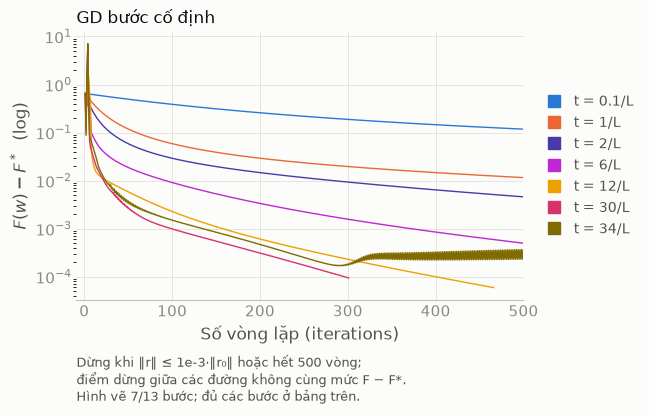

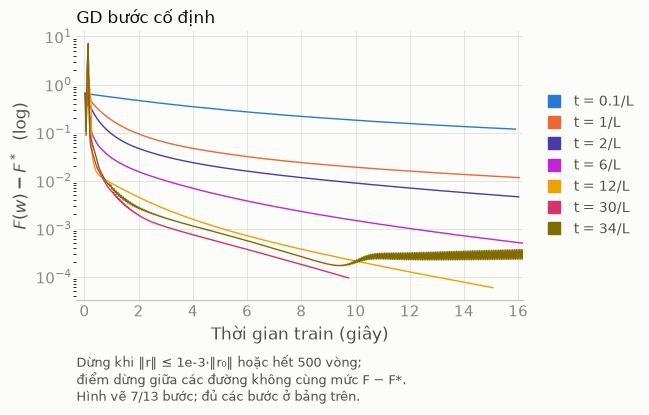

In [9]:
# ===== (1) GD buoc CO DINH: thu nhieu do dai buoc =====
BUOC = [0.1, 0.5, 1, 1.5, 2]        # boi cua 1/L (dung chung cho GD, Nesterov, Proximal)
# Buoc LON hon nguong 2/L cua ly thuyet: backtracking tu chon ~25/L nen buoc co dinh > 2/L van co the hoi tu.
# Dung CHUNG voi luoi o 6c (GD, Nesterov, FISTA) -> hinh quet va ket qua 6c cung mot tap setup.
BUOC_THEM = [2.5, 3, 4, 6]
# Buoc quanh CAN on dinh cuc bo cua GD: 2/lambda_max(H Ridge tai w*) ~ 32/L (tien_trinh.md muc 32).
BUOC_GD_LON = [12, 24, 30, 34]
BUOC_GD = sorted(set(BUOC + BUOC_THEM + BUOC_GD_LON))     # GD: 0.1 ... 34/L
duong_cd = [("t = %g/L" % k,)
            + gradient_descent(X_tr, y_tr, LAM, k / L0, VONG)[1:] for k in BUOC_GD]

in_bang(["Bước", "Trạng thái", "F cuối", "F − F*", "giây"],
        [[ten, trang_thai(F, VONG), "%.9f" % F[-1], "%.1e" % (F[-1] - F_SAO_R), "%.2f" % t[-1]]
         for ten, F, t in duong_cd], "GD bước cố định (ngân sách %d vòng)" % VONG)

# HINH chi ve 7 buoc, moi buoc mot y (bang tren in DU). Chon theo ket qua 6c (tien_trinh.md muc 32):
#   0.1/L qua nho | 1/L chuan ly thuyet | 2/L nguong an toan ly thuyet | 6/L best cu (luoi cu dung o day)
#   12/L giua | 30/L best t_eps moi | 34/L vuot can 2/lambda_max ~ 32/L -> khong hoi tu
VE_GD = [0.1, 1, 2, 6, 12, 30, 34]
ve_gd = [x for x, k in zip(duong_cd, BUOC_GD) if k in VE_GD]
ghi_gd = ghi_quet("%d vòng" % VONG) + "\nHình vẽ %d/%d bước; đủ các bước ở bảng trên." % (len(ve_gd), len(duong_cd))
ve(ve_gd, theo_thoi_gian=False, tieu_de="GD bước cố định", F_sao=F_SAO_R,
   luu="gd_codinh_vonglap.pdf", ghi_chu=ghi_gd)
ve(ve_gd, theo_thoi_gian=True,  tieu_de="GD bước cố định", F_sao=F_SAO_R,
   luu="gd_codinh_thoigian.pdf", ghi_chu=ghi_gd)


GD backtracking (ngân sách 500 vòng)
β, c                 Trạng thái           F cuối       F − F*   giây 
-------------------  -------------------  -----------  -------  -----
β = 0.1, c = 0.0001  hội tụ sau 164 vòng  0.043687423  5.7e-05  9.04 
β = 0.3, c = 0.0001  hội tụ sau 208 vòng  0.043685716  5.6e-05  12.37
β = 0.5, c = 0.0001  hội tụ sau 261 vòng  0.043665975  3.6e-05  17.39
β = 0.7, c = 0.0001  hội tụ sau 315 vòng  0.043646841  1.7e-05  26.21
β = 0.9, c = 0.0001  hội tụ sau 394 vòng  0.043633504  3.4e-06  63.96
β = 0.1, c = 0.01    hội tụ sau 164 vòng  0.043687423  5.7e-05  8.97 
β = 0.1, c = 0.1     hội tụ sau 181 vòng  0.043682904  5.3e-05  9.87 
β = 0.1, c = 0.3     hội tụ sau 186 vòng  0.043687648  5.8e-05  10.11
β = 0.5, c = 0.01    hội tụ sau 263 vòng  0.043665973  3.6e-05  17.43
β = 0.5, c = 0.1     hội tụ sau 260 vòng  0.043664565  3.4e-05  17.23
β = 0.5, c = 0.3     hội tụ sau 230 vòng  0.043670117  4.0e-05  15.22


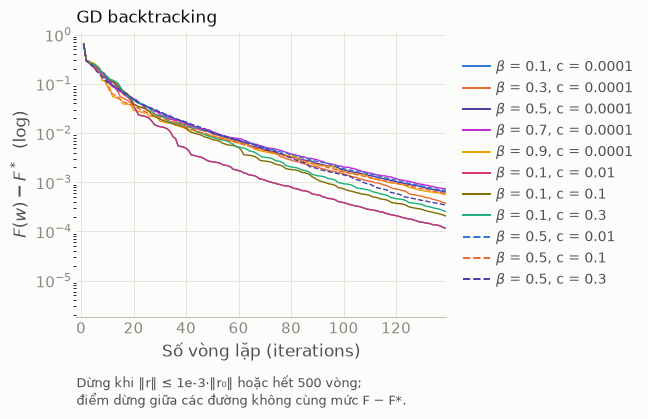

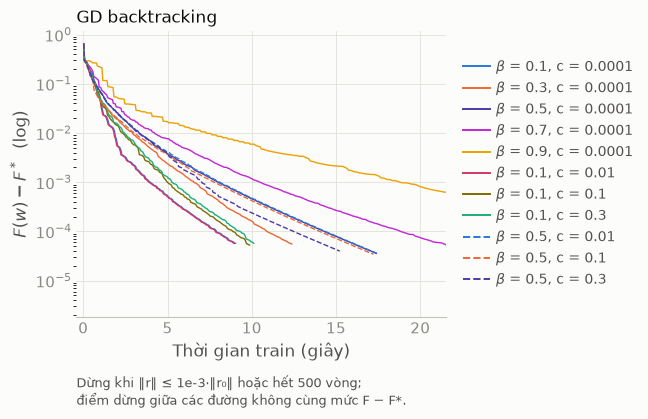

In [10]:
# ===== (2) GD BACKTRACKING: thu nhieu he so co buoc beta =====
# beta nho  -> co manh, it lan thu ben trong nhung buoc chon duoc tho
# beta lon  -> do ki, buoc sat nguong hon nhung moi vong phai tinh F nhieu lan
BETA = [0.1, 0.3, 0.5, 0.7, 0.9]
C_ARMIJO = [1e-4, 1e-2, 0.1, 0.3]          # he so Armijo c; dung chung voi luoi o 6c
LUOI_BT = [(b, 1e-4) for b in BETA] + [(b, c) for b in [0.1, 0.5] for c in C_ARMIJO if c != 1e-4]
duong_bt = [("$\\beta$ = %g, c = %g" % (b, c),) + gradient_descent_bt(X_tr, y_tr, LAM, VONG, beta=b, c=c)[1:]
            for b, c in LUOI_BT]

in_bang(["β, c", "Trạng thái", "F cuối", "F − F*", "giây"],
        [[ten, trang_thai(F, VONG), "%.9f" % F[-1], "%.1e" % (F[-1] - F_SAO_R), "%.2f" % t[-1]]
         for ten, F, t in duong_bt], "GD backtracking (ngân sách %d vòng)" % VONG)

ve(duong_bt, theo_thoi_gian=False, tieu_de="GD backtracking", F_sao=F_SAO_R,
   luu="gd_bt_vonglap.pdf", ghi_chu=ghi_quet("%d vòng" % VONG))
ve(duong_bt, theo_thoi_gian=True,  tieu_de="GD backtracking", F_sao=F_SAO_R,
   luu="gd_bt_thoigian.pdf", ghi_chu=ghi_quet("%d vòng" % VONG))

---
## 3b. GD tăng tốc (Nesterov)

GD thường chỉ đạt tốc độ $O(1/k)$ cho hàm lồi trơn. Nesterov chỉ ra cách đạt $O(1/k^2)$ mà
mỗi vòng vẫn rẻ như GD (một gradient) — mẹo là **không đi từ điểm đang đứng** mà đi từ một
**điểm ngoại suy** $v_k$, "nhìn trước" hướng mà $w$ vừa di chuyển:

$$w_{k+1}=v_k-t\nabla f(v_k),\qquad
v_{k+1}=w_{k+1}+\frac{\theta_k-1}{\theta_{k+1}}(w_{k+1}-w_k),\qquad
\theta_{k+1}=\frac{1+\sqrt{1+4\theta_k^2}}2,\quad\theta_0=1$$

$\theta_k\to\infty$ nên hệ số quán tính $(\theta_k-1)/\theta_{k+1}\to1$: càng về sau bước
ngoại suy càng dài, giống "đà" tích luỹ từ các bước trước.

Hai điều phải nhớ khi đọc hình:

- **Vẽ $F(w_k)$, không phải $F(v_k)$.** $w_k$ là điểm thật sự đang có; $v_k$ chỉ là nơi lấy
  gradient. $v_k$ có thể "vọt lố" nên $F(v_k)$ không đảm bảo giảm đơn điệu — dùng nó để vẽ
  sẽ ra đường gợn dù thuật toán vẫn đúng.
- **Vẫn dùng bước cố định $t=1/L$ như GD.** Nesterov không cần biết độ lồi mạnh của $f$,
  chỉ cần $L$, nên so với GD bước cố định là công bằng: cùng thông tin, khác cách dùng.

In [11]:
def gd_nesterov(X, y, lam, buoc, max_vong_lap=VONG, tol=TOL, max_giay=np.inf, F_dung=-np.inf):
    """GD tang toc (Nesterov) tren bai toan Ridge. v = diem ngoai suy, dao ham lay tai v;
    F ghi lai la F(w) (diem THUC dang co) vi F(v) khong dam bao giam don dieu.
    Gradient tai w chi de ghi F + kiem tra dung -> DUNG DONG HO luc tinh (day t0 len), nen moi
    vong chi tinh 1 gradient (tai v) nhu GD — so voi GD moi cong bang."""
    w = np.zeros(X.shape[1])
    v = w.copy()
    theta = 1.0
    F_list, t_list = [], []
    t0 = time.time()
    for i in range(max_vong_lap):
        t1 = time.time()
        F, g_w = ridge(w, X, y, lam)       # gradient tai w chi de kiem tra dieu kien dung
        t0 += time.time() - t1             # -> khong tinh vao thoi gian chay
        F_list.append(F)
        t_list.append(time.time() - t0)
        if i == 0:
            g0 = np.linalg.norm(g_w)
        if not np.isfinite(F) or np.linalg.norm(g_w) <= tol * g0 or t_list[-1] > max_giay or F <= F_dung:
            break
        g = ridge(v, X, y, lam)[1]
        w_moi = v - buoc * g
        theta_moi = (1 + np.sqrt(1 + 4 * theta ** 2)) / 2
        v = w_moi + (theta - 1) / theta_moi * (w_moi - w)
        w, theta = w_moi, theta_moi
    return w, F_list, t_list


GD Nesterov (ngân sách 500 vòng)
Bước       Trạng thái                   F cuối       F − F*   giây 
---------  ---------------------------  -----------  -------  -----
t = 0.1/L  chưa hội tụ (hết ngân sách)  0.043832406  2.0e-04  15.97
t = 0.5/L  hội tụ sau 454 vòng          0.043662311  3.2e-05  14.55
t = 1/L    hội tụ sau 317 vòng          0.043663768  3.4e-05  10.17
t = 1.5/L  hội tụ sau 205 vòng          0.043676764  4.7e-05  6.57 
t = 2/L    hội tụ sau 172 vòng          0.043676816  4.7e-05  5.50 
t = 2.5/L  hội tụ sau 151 vòng          0.043677138  4.7e-05  4.83 
t = 3/L    hội tụ sau 136 vòng          0.043677076  4.7e-05  4.37 
t = 4/L    hội tụ sau 116 vòng          0.043676914  4.7e-05  3.72 
t = 6/L    hội tụ sau 91 vòng           0.043661394  3.1e-05  2.92 
t = 8/L    hội tụ sau 93 vòng           0.043652473  2.2e-05  3.00 
t = 12/L   hội tụ sau 136 vòng          0.043668059  3.8e-05  4.40 
t = 14/L   hội tụ sau 139 vòng          0.043664694  3.5e-05  4.50 
t = 16/L   hội

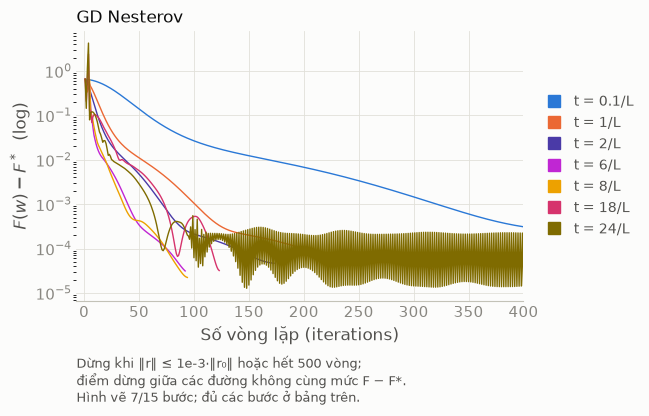

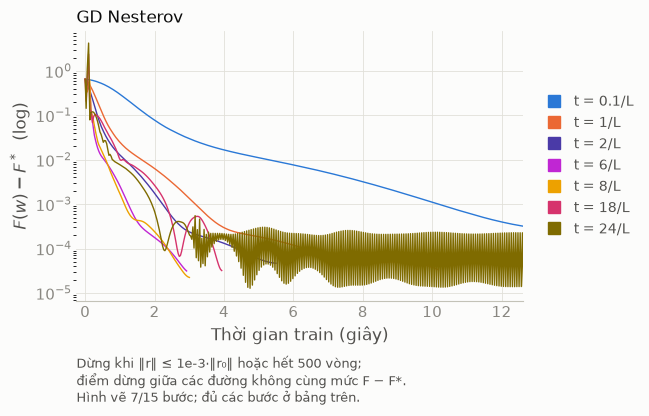


Cùng bước 1/L:  GD chưa hội tụ (hết ngân sách) (F = 0.055172310)   |   Nesterov hội tụ sau 317 vòng (F = 0.043663768)


In [12]:
# ===== GD Nesterov: thu nhieu do dai buoc (van la boi cua 1/L) =====
# Buoc quanh CAN cua Nesterov: 1/lambda_max(H Ridge tai w*) ~ 16/L (momentum: chat hon GD 2 lan; FISTA tren Lasso
# hong dung o ~1/lambda_max(H_S) ~ 65/L). Dung chung voi 6c (tien_trinh.md muc 32).
BUOC_NES_LON = [8, 12, 14, 16, 18, 24]
BUOC_NES = sorted(set(BUOC + BUOC_THEM + BUOC_NES_LON))
duong_acc = [("t = %g/L" % k,)
             + gd_nesterov(X_tr, y_tr, LAM, k / L0, VONG)[1:] for k in BUOC_NES]

in_bang(["Bước", "Trạng thái", "F cuối", "F − F*", "giây"],
        [[ten, trang_thai(F, VONG), "%.9f" % F[-1], "%.1e" % (F[-1] - F_SAO_R), "%.2f" % t[-1]]
         for ten, F, t in duong_acc], "GD Nesterov (ngân sách %d vòng)" % VONG)

# HINH chi ve 7 buoc (bang tren in DU). Chon theo ket qua 6c (tien_trinh.md muc 32):
#   0.1/L qua nho | 1/L chuan | 2/L | 6/L best t_eps (eps = 1e-6) | 8/L best o 1e-3, 1e-5
#   18/L lon nhat con hoi tu (can 1/lambda_max ~ 16/L) | 24/L khong hoi tu
VE_NES = [0.1, 1, 2, 6, 8, 18, 24]
ve_nes = [x for x, k in zip(duong_acc, BUOC_NES) if k in VE_NES]
ghi_nes = ghi_quet("%d vòng" % VONG) + "\nHình vẽ %d/%d bước; đủ các bước ở bảng trên." % (len(ve_nes), len(duong_acc))
ve(ve_nes, theo_thoi_gian=False, tieu_de="GD Nesterov", F_sao=F_SAO_R,
   luu="nesterov_vonglap.pdf", ghi_chu=ghi_nes)
ve(ve_nes, theo_thoi_gian=True,  tieu_de="GD Nesterov", F_sao=F_SAO_R,
   luu="nesterov_thoigian.pdf", ghi_chu=ghi_nes)

gd_1L, acc_1L = duong_cd[BUOC_GD.index(1)], duong_acc[BUOC_NES.index(1)]
print("\nCùng bước 1/L:  GD %s (F = %.9f)   |   Nesterov %s (F = %.9f)"
      % (trang_thai(gd_1L[1], VONG), gd_1L[1][-1], trang_thai(acc_1L[1], VONG), acc_1L[1][-1]))

---
## 3c. Newton

GD chỉ dùng đạo hàm bậc nhất nên phải đi theo $-\nabla F$ với một bước chung cho mọi hướng.
Newton dùng thêm **Hessian** để "nắn" hướng theo độ cong: hướng cong mạnh thì đi ngắn, hướng
thoải thì đi dài.

$$w_{k+1}=w_k-t_k\,d_k,\qquad \nabla^2F(w_k)\,d_k=\nabla F(w_k),\qquad
\nabla^2F(w)=\frac1nX^\top\mathrm{diag}\big(\sigma_i(1-\sigma_i)\big)X+\lambda I'$$

($I'$ là ma trận đơn vị bỏ phần tử của intercept, vì intercept không bị phạt.)

- **Bước cố định** $t_k=t$: $t=1$ là bước Newton thuần; $t<1$ gọi là *damped Newton*.
- **Backtracking**: mỗi vòng thử $t=1$ trước, chưa thoả Armijo
  $F(w-td)\le F(w)-c\,t\,\nabla F^\top d$ thì nhân $\beta$. Gần nghiệm $t=1$ luôn được nhận
  nên giữ được hội tụ **bậc hai**.

Mỗi vòng Newton đắt hơn GD nhiều (dựng Hessian $d\times d$ tốn $O(nd^2)$ và giải hệ $O(d^3)$),
nhưng ở đây $d\approx160$ vẫn nhỏ nên rẻ — và chỉ cần vài vòng. Vì vậy Newton chạy `VONG_NT` vòng
thay vì `VONG`.

In [13]:
def newton(X, y, lam, buoc=1.0, max_vong_lap=VONG_NT, tol=TOL, max_giay=np.inf, F_dung=-np.inf, backtracking=False, c=1e-4, beta=0.5,
           lich_su_buoc=None):
    """Newton tren bai toan Ridge. buoc = do dai buoc co dinh (bo qua neu backtracking=True);
    backtracking=True -> moi vong thu buoc 1 truoc, chua du giam (Armijo) thi nhan beta.
    lich_su_buoc = list -> them do dai buoc thuc su dung o moi vong (de biet backtracking co phai co buoc)."""
    w = np.zeros(X.shape[1])
    F_list, t_list = [], []
    phat = np.full(X.shape[1], lam)
    phat[0] = 0.0                                       # intercept khong bi phat
    t0 = time.time()
    for k in range(max_vong_lap):
        F, g = ridge(w, X, y, lam)
        F_list.append(F)
        t_list.append(time.time() - t0)
        if k == 0:
            g0 = np.linalg.norm(g)
        if not np.isfinite(F) or np.linalg.norm(g) <= tol * g0 or t_list[-1] > max_giay or F <= F_dung:
            break
        s = sigmoid(X @ w)
        s = s * (1 - s)
        H = X.T @ (X * s[:, None]) / len(y) + np.diag(phat)
        huong = np.linalg.solve(H, g)
        t = buoc
        if backtracking:
            t = 1.0
            giam = g @ huong                            # = g^T H^-1 g > 0
            while t > 1e-12 and F_ridge(w - t * huong, X, y, lam) > F - c * t * giam:
                t = t * beta
        if lich_su_buoc is not None:
            lich_su_buoc.append(t)
        w = w - t * huong
    return w, F_list, t_list

In [14]:
# ===== Newton: bước cố định (quét t) và backtracking (quét beta) =====
BUOC_NT = [0.1, 0.25, 0.5, 1.0]
duong_nt_cd = [("t = %g" % b,) + newton(X_tr, y_tr, LAM, buoc=b, max_vong_lap=VONG_NT)[1:] for b in BUOC_NT]
BETA_NT = [0.1, 0.5, 0.9]
BUOC_NT_BT = {b: [] for b in BETA_NT}          # buoc thuc su dung o moi vong cua backtracking
duong_nt_bt = [("$\\beta$ = %g" % b,) + newton(X_tr, y_tr, LAM, max_vong_lap=VONG_NT, backtracking=True, beta=b,
                                               lich_su_buoc=BUOC_NT_BT[b])[1:]
               for b in BETA_NT]

# Tim NGHIEM TOI UU Ridge bang chinh Newton tu viet: tol rat chat, cho them vong -> doi chieu F* cua sklearn
w_sao_R, F_nt_sao, t_nt_sao = newton(X_tr, y_tr, LAM, backtracking=True, max_vong_lap=100, tol=1e-10)
print("Nghiem toi uu Ridge (Newton bt, tol 1e-10): %s, F* = %.12f  (sklearn: %.12f, lech %.1e)  %.3g giây"
      % (trang_thai(F_nt_sao, 100), F_nt_sao[-1], F_SAO_R, F_nt_sao[-1] - F_SAO_R, t_nt_sao[-1]))

def co_buoc(ls):
    t_min = min(ls) if ls else 1.0
    return "không (t = 1 mọi vòng)" if t_min == 1.0 else "có (t nhỏ nhất = %g)" % t_min


in_bang(["Setup", "Trạng thái", "giây", "F − F*", "Bước có bị co?"],
        [["cố định " + ten, trang_thai(F, VONG_NT), "%.2f" % t[-1], "%.1e" % (F[-1] - F_SAO_R), "— (bước cố định)"]
         for ten, F, t in duong_nt_cd]
        + [["backtracking " + ten, trang_thai(F, VONG_NT), "%.2f" % t[-1], "%.1e" % (F[-1] - F_SAO_R), co_buoc(BUOC_NT_BT[b])]
           for (ten, F, t), b in zip(duong_nt_bt, BETA_NT)],
        "Newton (ngân sách %d vòng; mỗi đường chỉ vài điểm nên bảng rõ hơn hình)" % VONG_NT)

Nghiem toi uu Ridge (Newton bt, tol 1e-10): hội tụ sau 10 vòng, F* = 0.043630121211  (sklearn: 0.043630121211, lech 0.0e+00)  3.42 giây

Newton (ngân sách 30 vòng; mỗi đường chỉ vài điểm nên bảng rõ hơn hình)
Setup                 Trạng thái                   giây  F − F*   Bước có bị co?        
--------------------  ---------------------------  ----  -------  ----------------------
cố định t = 0.1       chưa hội tụ (hết ngân sách)  9.54  1.9e-02  — (bước cố định)      
cố định t = 0.25      hội tụ sau 27 vòng           8.80  3.6e-05  — (bước cố định)      
cố định t = 0.5       hội tụ sau 13 vòng           4.35  3.2e-05  — (bước cố định)      
cố định t = 1         hội tụ sau 6 vòng            2.01  2.0e-05  — (bước cố định)      
backtracking β = 0.1  hội tụ sau 6 vòng            2.13  2.0e-05  không (t = 1 mọi vòng)
backtracking β = 0.5  hội tụ sau 6 vòng            2.07  2.0e-05  không (t = 1 mọi vòng)
backtracking β = 0.9  hội tụ sau 6 vòng            2.11  2.0e-05  không (t = 1 

---
## 4. SGD

Khác GD duy nhất ở chỗ **dùng bao nhiêu điểm để tính gradient mỗi lần cập nhật**. Gradient
thật là trung bình trên cả $n$ điểm; SGD thay nó bằng trung bình trên một **mini-batch** $B$
điểm lấy ngẫu nhiên:

$$\nabla\ell(w)\;\approx\;\frac1B\sum_{i\in\mathcal{B}}\nabla\ell_i(w)$$

Ước lượng này **không chệch** nhưng có phương sai $\sigma^2/B$. Rẻ hơn $n/B$ lần nên đi được
nhiều bước hơn hẳn trong cùng thời gian, đổi lại đường đi zíc zắc và **không dừng hẳn**: với
bước cố định nó chỉ lảng vảng quanh nghiệm trong một "quả cầu nhiễu". Muốn hội tụ thật phải
cho bước teo dần theo điều kiện Robbins-Monro:

$$\sum_k\eta_k=\infty,\qquad\sum_k\eta_k^2<\infty\quad\Longrightarrow\quad
\eta_k=\frac{\eta_0}{1+k}\ \ \text{hoặc}\ \ \frac{\eta_0}{\sqrt{1+k}}$$

Hai quyết định về cách đo, không thì so sánh sai:

- **Không dùng $B=1$.** Ở đây $d\approx160$, một bước SGD là phép nhân trên vector vài trăm phần tử —
  overhead của numpy nuốt trọn thời gian tính, trong khi một bước GD là **một** lệnh BLAS
  trên ma trận lớn chạy hết công suất CPU. $B=1$ sẽ chậm hơn GD theo giây dù ít phép tính hơn.
- **Trục hoành đếm theo epoch.** Một epoch SGD = một lượt đọc hết dữ liệu = $n/B$ lần cập
  nhật, ngang chi phí một vòng GD. Nếu đếm theo lần cập nhật thì đường GD co lại thành một
  cái chấm. Đại lượng đem vẽ là **loss trên chính mini-batch** sắp dùng để cập nhật (ghi `DO_MOI`
  lần mỗi epoch), nên đường **gợn** đúng bản chất nhiễu của SGD. Đồng hồ **tạm dừng** lúc
  ghi — phép đo là để vẽ hình, không phải chi phí của thuật toán.

**Điều kiện dừng của SGD**: gradient mini-batch nhiễu nên không dùng để dừng được. Cuối mỗi epoch
tính $\|\nabla F\|$ trên **toàn bộ** dữ liệu (đồng hồ tạm dừng, như lúc ghi loss) và dừng khi đạt
cùng ngưỡng `TOL` như GD. Với bước cố định, SGD chỉ lảng vảng trong quả cầu nhiễu nên thường
**không** đạt được — đúng như lý thuyết.

**Backtracking không dùng được cho SGD**: điều kiện Armijo cần so $F$ trước/sau, mà $F$ trên
mini-batch là số nhiễu nên nó sẽ chấp nhận hoặc từ chối bừa.

In [15]:
def sgd(X, y, lam, eta0, batch=4096, max_vong_lap=EPOCH, tol=TOL, max_giay=np.inf, F_dung=-np.inf, lich="1/k", seed=0, do_moi=10,
        lich_su_F=None):
    """SGD mini-batch tren Ridge. Tra ve w + lich su loss, thoi gian.
       lich   = "co dinh" -> eta khong doi
              = "1/k"     -> eta0 / (1 + k)
              = "1/sqrt"  -> eta0 / sqrt(1 + k)          (k = so epoch da chay)
       max_vong_lap = so EPOCH toi da;  tol = nguong dung tren ||grad F|| toan bo.
       lich_su_F = list -> them (F toan bo, giay) cuoi moi epoch (de tinh F - F* cho SGD).
       do_moi = ghi loss bao nhieu lan trong moi epoch (chi de ve hinh).
    Diem dau la F(0) tren toan bo du lieu; cac diem sau la loss tren CHINH mini-batch sap
    dung de cap nhat -> do thi gon, dung ban chat nhieu cua SGD (F toan bo thi muot, xem muc duoi)."""
    rng = np.random.default_rng(seed)
    n_ = X.shape[0]
    so_batch = (n_ + batch - 1) // batch
    # DUNG "so_batch // do_moi": lam tron xuong se ra nhieu hon do_moi lan do moi epoch,
    # truc hoanh se dai hon so epoch that. Chot cung dung do_moi moc bang linspace.
    do_moi = min(do_moi, so_batch)
    moc = set(np.linspace(so_batch / do_moi, so_batch, do_moi).astype(int) - 1)
    w = np.zeros(X.shape[1])
    F0, g = ridge(w, X, y, lam)
    F_list, t_list, g0 = [F0], [0.0], np.linalg.norm(g)
    tong = 0.0

    for k in range(max_vong_lap):
        eta = (eta0 if lich == "co dinh" else
               eta0 / (1 + k) if lich == "1/k" else eta0 / np.sqrt(1 + k))
        thu_tu = rng.permutation(n_)
        for j in range(so_batch):
            t0 = time.time()
            idx = thu_tu[j * batch:(j + 1) * batch]
            Xb, yb = X[idx], y[idx]
            tong += time.time() - t0
            if j in moc:                       # dong ho DUNG trong luc ghi loss
                F_list.append(ridge(w, Xb, yb, lam)[0])
                t_list.append(tong)
            t0 = time.time()
            g = Xb.T @ (sigmoid(Xb @ w) - yb) / len(idx)
            g[1:] += lam * w[1:]
            w = w - eta * g
            tong += time.time() - t0
        if not np.isfinite(F_list[-1]):
            break
        # dieu kien dung: ||grad F|| tren TOAN BO du lieu, cuoi moi epoch (dong ho dang dung)
        F_ep, g_ep = ridge(w, X, y, lam)
        if lich_su_F is not None:
            lich_su_F.append((F_ep, tong))
        if np.linalg.norm(g_ep) <= tol * g0 or tong > max_giay or F_ep <= F_dung:
            break
    return w, F_list, t_list


SGD bước cố định (batch 4096, 42 epoch)
α0         Trạng thái                   loss mini-batch epoch cuối  giây
---------  ---------------------------  --------------------------  ----
α0 = 0.01  chưa hội tụ (hết ngân sách)  0.063311585                 30.8
α0 = 0.05  chưa hội tụ (hết ngân sách)  0.046309468                 30.8
α0 = 0.2   chưa hội tụ (hết ngân sách)  0.044234274                 30.7
α0 = 1     chưa hội tụ (hết ngân sách)  0.044296401                 30.7
α0 = 5     chưa hội tụ (hết ngân sách)  0.047352948                 30.7


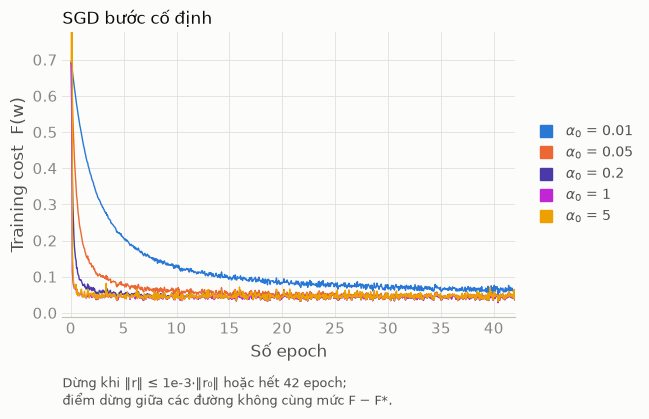

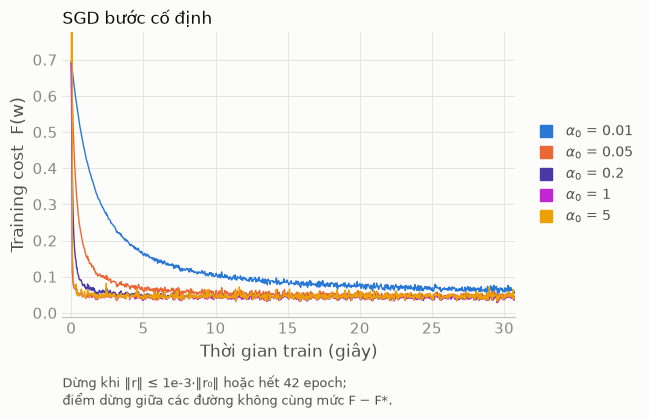

In [16]:
# ===== (1) SGD: quet do dai buoc dau eta0, buoc CO DINH =====
ETA = [0.01, 0.05, 0.2, 1.0, 5.0]
duong_sgd = [("$\\alpha_0$ = %g" % e,) + sgd(X_tr, y_tr, LAM, e, max_vong_lap=EPOCH, do_moi=DO_MOI, lich="co dinh")[1:]
             for e in ETA]

in_bang(["α0", "Trạng thái", "loss mini-batch epoch cuối", "giây"],
        [[ten, trang_thai(F[::DO_MOI], EPOCH + 1, "epoch"),
          "phân kỳ" if not np.isfinite(F[-1]) else "%.9f" % diem_cuoi(F, trung_binh=True), "%.1f" % t[-1]]
         for ten, F, t in duong_sgd], "SGD bước cố định (batch 4096, %d epoch)" % EPOCH)

ve(duong_sgd, theo_thoi_gian=False, ten_x="Số epoch", chia_x=DO_MOI,
   tieu_de="SGD bước cố định", luu="sgd_eta_epoch.pdf", ghi_chu=ghi_quet("%d epoch" % EPOCH))
ve(duong_sgd, theo_thoi_gian=True,
   tieu_de="SGD bước cố định", luu="sgd_eta_thoigian.pdf", ghi_chu=ghi_quet("%d epoch" % EPOCH))

alpha0 (learning rate) tot nhat o buoc co dinh: 0.2



SGD: lịch giảm bước × α0 (F trên toàn bộ dữ liệu, 42 epoch)
α0   Lịch     Trạng thái                   F − F* cuối  giây
---  -------  ---------------------------  -----------  ----
0.2  cố định  chưa hội tụ (hết ngân sách)  6.13e-05     30.7
0.2  1/√k     chưa hội tụ (hết ngân sách)  1.90e-03     30.8
0.2  1/k      chưa hội tụ (hết ngân sách)  9.01e-03     30.7
1    cố định  chưa hội tụ (hết ngân sách)  8.72e-05     30.7
1    1/√k     chưa hội tụ (hết ngân sách)  1.54e-05     30.9
1    1/k      chưa hội tụ (hết ngân sách)  4.63e-04     30.6


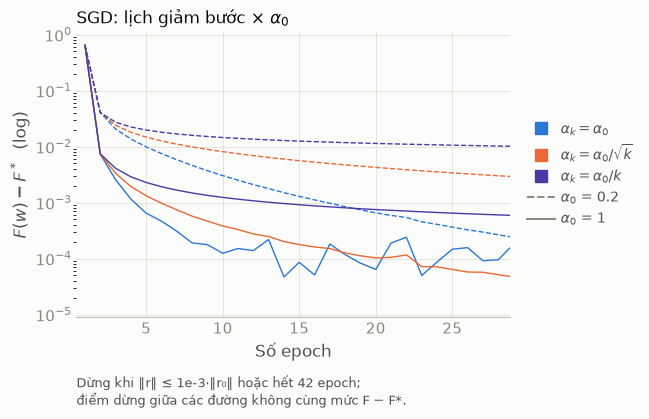

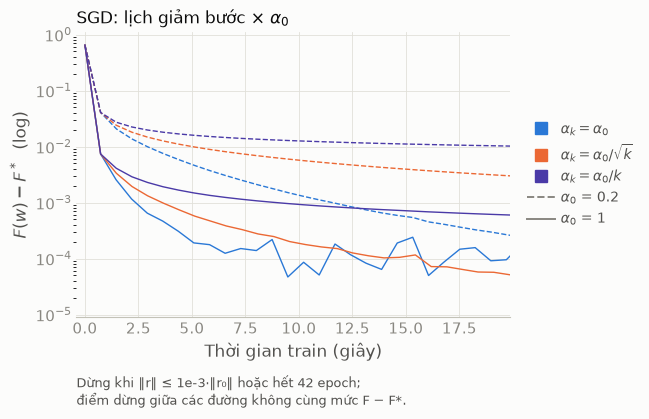

In [17]:
# ===== (2) SGD: doi LICH TEO BUOC, voi 2 gia tri alpha0 =====
# alpha0 tot nhat cua buoc CO DINH (eta_tot) chua chac hop voi lich giam buoc: buoc teo qua som.
# Nen thu them alpha0 = 1. So bang F TOAN BO cuoi moi epoch (lich_su_F), khong dung loss mini-batch:
# chenh lech giua cac lich o vung cuoi nho hon muc nhieu cua loss mini-batch.
eta_tot = ETA[int(np.argmin([diem_cuoi(F, trung_binh=True) for _, F, _ in duong_sgd]))]
print("alpha0 (learning rate) tot nhat o buoc co dinh:", eta_tot)

LICH = ["co dinh", "1/sqrt", "1/k"]
TEN_LICH = {"co dinh": r"$\alpha_k=\alpha_0$",
            "1/sqrt":  r"$\alpha_k=\alpha_0/\sqrt{k}$",
            "1/k":     r"$\alpha_k=\alpha_0/k$"}
ETA_LICH = [eta_tot, 1.0] if eta_tot != 1.0 else [1.0, 0.2]
SGD_F = {}                       # (alpha0, lich) -> (F toan bo cuoi moi epoch, giay)
for e in ETA_LICH:
    for l in LICH:
        ls = [(ridge(np.zeros(d), X_tr, y_tr, LAM)[0], 0.0)]
        sgd(X_tr, y_tr, LAM, e, max_vong_lap=EPOCH, do_moi=DO_MOI, lich=l, lich_su_F=ls)
        SGD_F[e, l] = ([f for f, _ in ls], [g for _, g in ls])

in_bang(["α0", "Lịch", "Trạng thái", "F − F* cuối", "giây"],
        [["%g" % e, TEN_LICH[l], trang_thai(SGD_F[e, l][0], EPOCH + 1, "epoch"),
          "%.2e" % (SGD_F[e, l][0][-1] - F_SAO_R), "%.1f" % SGD_F[e, l][1][-1]] for e in ETA_LICH for l in LICH],
        "SGD: lịch giảm bước × α0 (F trên toàn bộ dữ liệu, %d epoch)" % EPOCH)

# mau = lich, kieu net = alpha0
duong_lich = [(TEN_LICH[l] + r", $\alpha_0$ = %g" % e,) + SGD_F[e, l] for e in ETA_LICH for l in LICH]
kieu = dict(mau=MAU[:len(LICH)], net=["--"] * len(LICH) + ["-"] * len(LICH), F_sao=F_SAO_R,
            chu=[(TEN_LICH[l], c) for l, c in zip(LICH, MAU)]
                + [(r"$\alpha_0$ = %g" % e, MO, ls, None) for e, ls in zip(ETA_LICH, ["--", "-"])],
            tieu_de="SGD: lịch giảm bước × $\\alpha_0$", ghi_chu=ghi_quet("%d epoch" % EPOCH))
ve(duong_lich, theo_thoi_gian=False, ten_x="Số epoch", luu="sgd_lich_epoch.pdf", **kieu)
ve(duong_lich, theo_thoi_gian=True, luu="sgd_lich_thoigian.pdf", **kieu)

---
## 5. Subgradient cho Lasso

Lasso thêm $\lambda_1\|w\|_1$, mà $|w_j|$ **không khả vi tại 0** nên không có gradient. Thay
vào đó dùng một phần tử bất kỳ của **dưới vi phân**:

$$\partial|w_j|=\begin{cases}\{\operatorname{sign}(w_j)\} & w_j\neq0\\[2pt]
[-1,\,1] & w_j=0\end{cases}$$

Ở toạ độ đang bằng 0 ta được cả một đoạn để chọn. Chọn **phần tử có chuẩn nhỏ nhất**, tức
đẩy $\nabla_j\ell$ ra ngoài đoạn $[-\lambda_1,\lambda_1]$:

$$s_j=\nabla_j\ell-\operatorname{clip}\big(\nabla_j\ell,\,-\lambda_1,\,\lambda_1\big)$$

Chọn thế có hai cái lợi. Thứ nhất, khi $|\nabla_j\ell|\le\lambda_1$ thì $s_j=0$ — toạ độ **đang
bằng 0** thì đứng yên tại 0. Thứ hai, $\|s\|$ chính là thước đo tối ưu KKT: $s=0$ khi và chỉ khi
$w$ là nghiệm.

**Nhưng trên thực tế subgradient không cho nghiệm thưa**: xuất phát từ $w_0=0$, ngay bước đầu hầu hết
toạ độ rời khỏi 0, và một toạ độ khác 0 chỉ quay lại được 0 nếu bước subgradient rơi **đúng** vào 0 —
điều hầu như không xảy ra. Output ở dưới cho khoảng 154/160 hệ số khác 0, trong khi ISTA/FISTA (mục
5b) chỉ còn khoảng 20/160 nhờ bước prox đặt hẳn hệ số về 0.

Hai điều phải nhớ khi đọc hình:

- **Đây không phải phương pháp giảm.** $F$ có thể tăng ở một số vòng, hoàn toàn bình thường —
  đường sẽ gợn chứ không mượt như GD.
- **Bước bắt buộc teo dần.** Với bước cố định, $\|s\|$ không tiến về 0 ở lân cận nghiệm nên
  $F$ dao động mãi. Tốc độ chỉ đạt $O(1/\sqrt{k})$, chậm hơn hẳn GD — đó là cái giá của việc
  mất tính khả vi.

In [18]:
def subgradient(X, y, lam1, eta0, max_vong_lap=VONG, tol=TOL, max_giay=np.inf, F_dung=-np.inf, lich="1/sqrt"):
    """Subgradient cho Lasso, chon phan tu CHUAN NHO NHAT cua duoi vi phan.
    Intercept (cot 0) khong bi phat nen giu nguyen gradient."""
    w = np.zeros(X.shape[1])
    F_list, t_list = [], []
    t0 = time.time()
    for k in range(max_vong_lap):
        F, g = lasso(w, X, y, lam1)          # g = gradient cua RIENG phan log-loss
        F_list.append(F)
        t_list.append(time.time() - t0)
        if not np.isfinite(F):
            break
        khac0 = np.zeros(len(w), bool)
        bang0 = np.zeros(len(w), bool)
        khac0[1:] = w[1:] != 0
        bang0[1:] = w[1:] == 0
        s = g.copy()
        s[khac0] += lam1 * np.sign(w[khac0])                     # w_j != 0: dao ham thuong
        s[bang0] = g[bang0] - np.clip(g[bang0], -lam1, lam1)     # w_j == 0: phan tu chuan nho nhat
        if k == 0:
            s0 = np.linalg.norm(s)
        if np.linalg.norm(s) <= tol * s0 or t_list[-1] > max_giay or F <= F_dung:                        # ||s|| = thuoc do KKT -> dieu kien dung
            break
        eta = eta0 / (1 + k) if lich == "1/k" else eta0 / np.sqrt(1 + k)
        w = w - eta * s
    return w, F_list, t_list


Subgradient (Lasso, ngân sách 500 vòng)
α0        Trạng thái                   F cuối       Hệ số ≠ 0  giây 
--------  ---------------------------  -----------  ---------  -----
α0 = 0.5  chưa hội tụ (hết ngân sách)  0.087898384  118/160    16.18
α0 = 2    chưa hội tụ (hết ngân sách)  0.057027982  154/160    15.80
α0 = 8    chưa hội tụ (hết ngân sách)  0.050041392  154/160    16.08
α0 = 30   chưa hội tụ (hết ngân sách)  0.054111065  122/160    16.09
α0 = 100  chưa hội tụ (hết ngân sách)  0.099183189  124/160    16.08


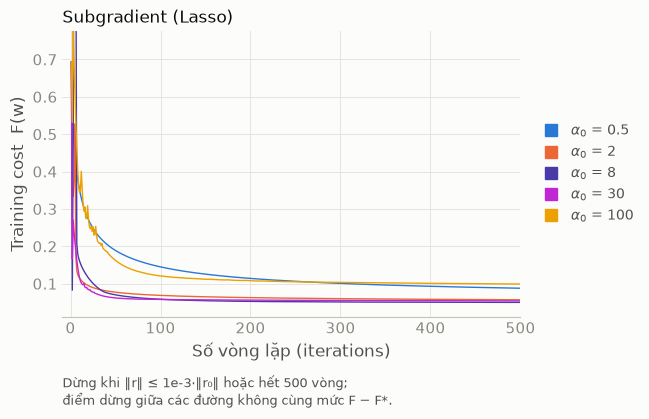

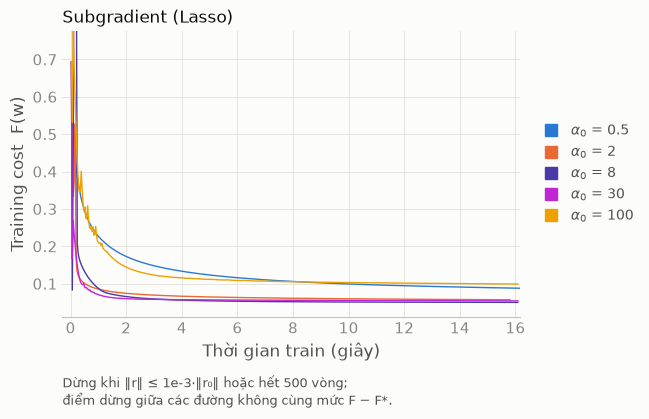

In [19]:
# ===== Subgradient: quet eta0 =====
ETA_SG = [0.5, 2.0, 8.0, 30.0, 100.0]
duong_sg, W_SG = [], []
for e in ETA_SG:
    w_sg, F, t = subgradient(X_tr, y_tr, LAM1, e, max_vong_lap=VONG)
    duong_sg.append((r"$\alpha_0$ = %g" % e, F, t))
    W_SG.append(w_sg)
in_bang(["α0", "Trạng thái", "F cuối", "Hệ số ≠ 0", "giây"],
        [[ten, trang_thai(F, VONG), "%.9f" % F[-1], "%d/%d" % (np.sum(w[1:] != 0), d - 1), "%.2f" % t[-1]]
         for (ten, F, t), w in zip(duong_sg, W_SG)], "Subgradient (Lasso, ngân sách %d vòng)" % VONG)

ve(duong_sg, theo_thoi_gian=False, tieu_de="Subgradient (Lasso)",
   luu="subgrad_vonglap.pdf", ghi_chu=ghi_quet("%d vòng" % VONG))
ve(duong_sg, theo_thoi_gian=True,  tieu_de="Subgradient (Lasso)",
   luu="subgrad_thoigian.pdf", ghi_chu=ghi_quet("%d vòng" % VONG))

---
## 5b. Proximal gradient (ISTA) cho Lasso

Subgradient ở trên phải dùng bước **teo dần** ($O(1/\sqrt k)$) vì thông tin "không khả vi
tại 0" bị trộn thẳng vào một bước gradient chung. Cách khác: **tách riêng** phần trơn và
phần không trơn — đi một bước gradient trên $\ell$ (phần trơn) rồi "chốt" kết quả bằng
**prox** của $\lambda_1\|\cdot\|_1$:

$$w_{k+1}=\operatorname{prox}_{t\lambda_1\|\cdot\|_1}\big(w_k-t\nabla\ell(w_k)\big),
\qquad
\operatorname{prox}_{t\lambda_1\|\cdot\|_1}(v)_j=\operatorname{sign}(v_j)\max(|v_j|-t\lambda_1,\,0)$$

Đây gọi là **ISTA** (Iterative Shrinkage-Thresholding). Hai điểm khác subgradient:

- **Bước cố định $t=1/L$ dùng được luôn** — $L$ ở đây là hằng số Lipschitz của riêng $\ell$
  (không cộng $\lambda_2$ vì Lasso không có phần $L_2$), đúng bằng `L0` đã tính ở mục 3.
  Tốc độ hội tụ $O(1/k)$, nhanh hơn hẳn $O(1/\sqrt k)$ của subgradient.
- **Đặt hẳn hệ số về 0** trong một bước duy nhất (soft-threshold co thẳng những $|v_j|\le
  t\lambda_1$ về 0), trong khi subgradient chỉ *ngừng di chuyển* toạ độ đó khi may mắn rơi
  trúng 0.

**FISTA** — thêm gia tốc Nesterov y như mục 3b, nhưng bước prox lấy tại điểm ngoại suy $v_k$:

$$w_{k+1}=\operatorname{prox}_{t\lambda_1\|\cdot\|_1}\big(v_k-t\nabla\ell(v_k)\big),\qquad
v_{k+1}=w_{k+1}+\frac{\theta_k-1}{\theta_{k+1}}(w_{k+1}-w_k)$$

Tốc độ $O(1/k^2)$ thay vì $O(1/k)$ của ISTA, mỗi vòng vẫn chỉ một gradient + một prox.

In [20]:
def prox_l1(v, t, lam1):
    """prox cua g = lam1*||.||_1: soft-threshold. Cot 0 (intercept) khong bi phat -> giu nguyen."""
    out = np.sign(v) * np.maximum(np.abs(v) - t * lam1, 0)
    out[0] = v[0]
    return out


def proximal_gradient(X, y, lam1, buoc, max_vong_lap=VONG, tol=TOL, max_giay=np.inf, F_dung=-np.inf, gia_toc=False):
    """ISTA cho Lasso: buoc gradient tren phan tron (log-loss) roi prox cho lam1*||w||_1.
    gia_toc=True -> FISTA: lay gradient + prox tai diem ngoai suy v (giong Nesterov);
    F ghi lai tai w (diem that), vi F(v) khong dam bao giam. FISTA: gradient tai w chi de ghi F +
    kiem tra dung -> dung dong ho luc tinh (nhu gd_nesterov). ISTA dung gradient do de di -> van tinh gio."""
    w = np.zeros(X.shape[1])
    v, theta = w.copy(), 1.0
    F_list, t_list = [], []
    t0 = time.time()
    for i in range(max_vong_lap):
        t1 = time.time()
        F, g = lasso(w, X, y, lam1)
        if gia_toc:
            t0 += time.time() - t1             # FISTA: khong tinh vao thoi gian chay
        F_list.append(F)
        t_list.append(time.time() - t0)
        if not np.isfinite(F):
            break
        G = np.linalg.norm(w - prox_l1(w - buoc * g, buoc, lam1)) / buoc   # gradient mapping tai w
        if i == 0:
            G0 = G
        if G <= tol * G0 or t_list[-1] > max_giay or F <= F_dung:                                                # = 0 <=> w la nghiem
            break
        if gia_toc:
            g = lasso(v, X, y, lam1)[1]
        w_moi = prox_l1(v - buoc * g, buoc, lam1)
        if gia_toc:
            theta_moi = (1 + np.sqrt(1 + 4 * theta ** 2)) / 2
            v = w_moi + (theta - 1) / theta_moi * (w_moi - w)
            theta = theta_moi
        else:
            v = w_moi
        w = w_moi
    return w, F_list, t_list


Proximal (Lasso, ngân sách 500 vòng)
Thuật toán  Bước       Trạng thái                   F cuối       Hệ số ≠ 0  giây 
----------  ---------  ---------------------------  -----------  ---------  -----
ISTA        t = 0.1/L  chưa hội tụ (hết ngân sách)  0.161996380  38/160     15.76
ISTA        t = 0.5/L  chưa hội tụ (hết ngân sách)  0.069209081  35/160     15.92
ISTA        t = 1/L    chưa hội tụ (hết ngân sách)  0.058282609  30/160     15.81
ISTA        t = 1.5/L  chưa hội tụ (hết ngân sách)  0.054151996  27/160     15.79
ISTA        t = 2/L    chưa hội tụ (hết ngân sách)  0.051836388  26/160     15.77
ISTA        t = 6/L    chưa hội tụ (hết ngân sách)  0.047369305  26/160     15.94
ISTA        t = 19/L   hội tụ sau 379 vòng          0.046582066  21/160     12.24
ISTA        t = 29/L   chưa hội tụ (hết ngân sách)  0.046683405  19/160     16.12
ISTA        t = 32/L   chưa hội tụ (hết ngân sách)  0.046805429  19/160     16.11
ISTA        t = 48/L   chưa hội tụ (hết ngân sách)  0.051972

Nghiem toi uu Lasso (FISTA, tol 1e-6): chưa hội tụ (hết ngân sách), F = 0.046538164358, he so khac 0: 19/160  161 giây
F* Lasso = 0.046538164358


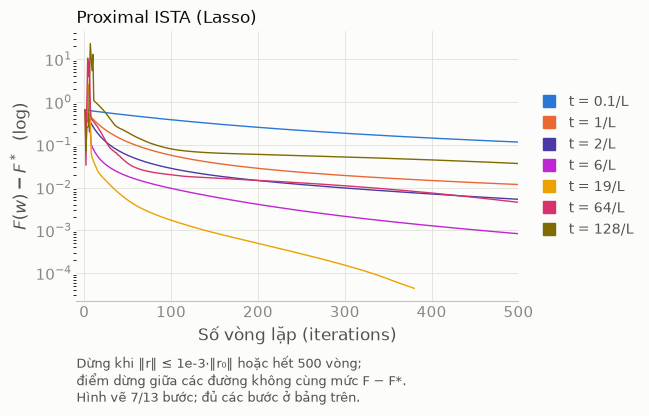

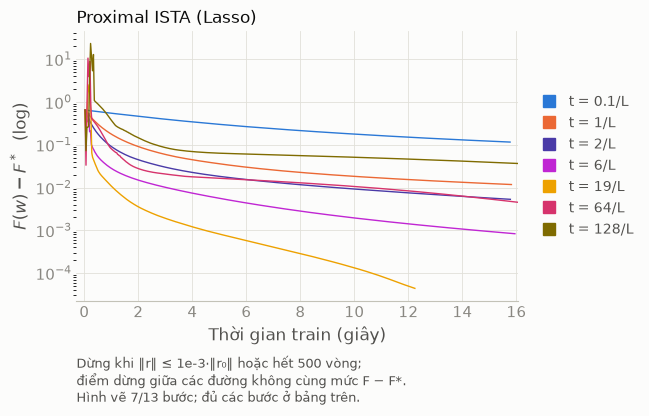

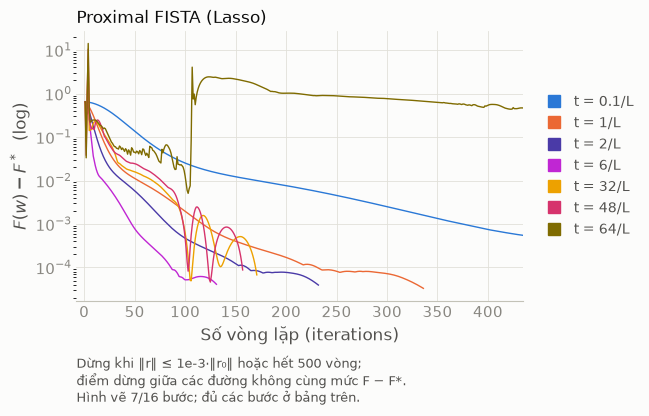

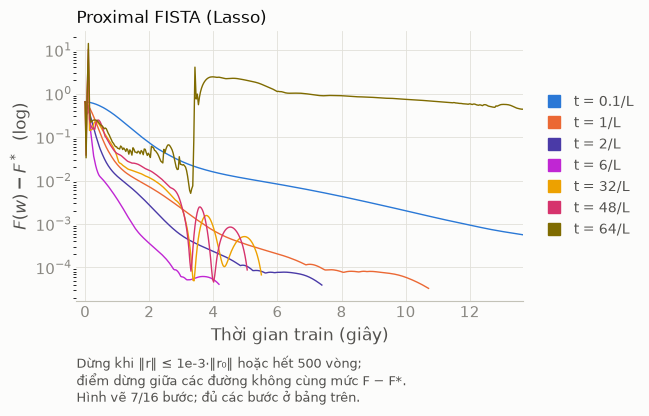

In [21]:
# ===== Proximal: ISTA va FISTA (co gia toc), thu nhieu do dai buoc (boi cua 1/L) =====
# Buoc RAT LON cho ISTA / FISTA: 6/L van la best o bien luoi -> thu tiep.
# Nguong on dinh CUC BO cua prox-gradient la 2/lambda_max(H_S), H_S = Hessian phan TRON (log-loss, khong +lam*I)
# chi tren tap ho tro S tai w*_Lasso: ~130/L. KHONG dung lambda_max cua H Ridge (~0.39 -> 2/lambda_max ~ 32/L).
BUOC_PX_LON = [19, 29, 32, 48, 64, 96, 128]     # 64-128/L: sat nguong cuc bo 2/lambda_max(H_S) ~ 130/L
BUOC_ISTA = BUOC + [6] + BUOC_PX_LON     # ISTA: them 6/L (so cap voi FISTA 6/L) va cac buoc rat lon; dung chung voi 6c
BUOC_FISTA = sorted(set(BUOC + BUOC_THEM)) + BUOC_PX_LON      # FISTA: 0.1 ... 6/L + cac buoc rat lon; dung chung voi 6c
duong_prox, duong_fista, W_PX = [], [], []      # W_PX: w cua ISTA roi FISTA, cung thu tu duong_prox + duong_fista
for gia_toc, ds, luoi_px in [(False, duong_prox, BUOC_ISTA), (True, duong_fista, BUOC_FISTA)]:   # luoi nhu 6c
    for k in luoi_px:
        w_px, F, t = proximal_gradient(X_tr, y_tr, LAM1, k / L0, VONG, gia_toc=gia_toc)
        ds.append(("t = %g/L" % k, F, t))
        W_PX.append(w_px)
in_bang(["Thuật toán", "Bước", "Trạng thái", "F cuối", "Hệ số ≠ 0", "giây"],
        [[tt, ten, trang_thai(F, VONG), "%.9f" % F[-1], "%d/%d" % (np.sum(w[1:] != 0), d - 1), "%.2f" % t[-1]]
         for tt, (ten, F, t), w in zip(["ISTA"] * len(duong_prox) + ["FISTA"] * len(duong_fista),
                                       duong_prox + duong_fista, W_PX)], "Proximal (Lasso, ngân sách %d vòng)" % VONG)

# Tim NGHIEM TOI UU Lasso: FISTA buoc 1/L, tol rat chat, ngan sach lon (Lasso khong co Newton)
w_sao_L, F_fi_sao, t_fi_sao = proximal_gradient(X_tr, y_tr, LAM1, 1 / L0, max_vong_lap=5000, tol=1e-6, gia_toc=True)
print("Nghiem toi uu Lasso (FISTA, tol 1e-6): %s, F = %.12f, he so khac 0: %d/%d  %.3g giây"
      % (trang_thai(F_fi_sao, 5000), F_fi_sao[-1], np.sum(w_sao_L[1:] != 0), d - 1, t_fi_sao[-1]))
F_SAO_L = min([F_fi_sao[-1]] + [np.nanmin(F) for _, F, _ in duong_sg + duong_prox + duong_fista])
print("F* Lasso = %.12f" % F_SAO_L)

# HINH chi ve 7 buoc, moi buoc mot y (bang tren in DU moi buoc). Chon theo ket qua 6c (tien_trinh.md muc 31):
#   0.1/L qua nho | 1/L chuan ly thuyet | 2/L nguong an toan ly thuyet | 6/L, best ISTA 19/L, best FISTA 32/L (1e-6)
#   ISTA 64/L, 128/L: buoc lon toi 1e-3 rat cham (128/L sat nguong cuc bo ~130/L)
#   FISTA 48/L: lon nhat con hoi tu | FISTA 64/L: bat dau hong (96, 128/L cung y)
VE_ISTA = [0.1, 1, 2, 6, 19, 64, 128]
VE_FISTA = [0.1, 1, 2, 6, 32, 48, 64]
giu = lambda ds, luoi_ds, chon: [x for x, k in zip(ds, luoi_ds) if k in chon]
ve_ista, ve_fista = giu(duong_prox, BUOC_ISTA, VE_ISTA), giu(duong_fista, BUOC_FISTA, VE_FISTA)
ghi = lambda ve_ds, ds: ghi_quet("%d vòng" % VONG) + "\nHình vẽ %d/%d bước; đủ các bước ở bảng trên." % (len(ve_ds), len(ds))
ve(ve_ista, theo_thoi_gian=False, tieu_de="Proximal ISTA (Lasso)", F_sao=F_SAO_L, luu="proximal_vonglap.pdf", ghi_chu=ghi(ve_ista, duong_prox))
ve(ve_ista, theo_thoi_gian=True,  tieu_de="Proximal ISTA (Lasso)", F_sao=F_SAO_L, luu="proximal_thoigian.pdf", ghi_chu=ghi(ve_ista, duong_prox))
ve(ve_fista, theo_thoi_gian=False, tieu_de="Proximal FISTA (Lasso)", F_sao=F_SAO_L, luu="fista_vonglap.pdf", ghi_chu=ghi(ve_fista, duong_fista))
ve(ve_fista, theo_thoi_gian=True,  tieu_de="Proximal FISTA (Lasso)", F_sao=F_SAO_L, luu="fista_thoigian.pdf", ghi_chu=ghi(ve_fista, duong_fista))


---
## 6c. Kết quả chính: thời gian tới $F - F^\star \le \varepsilon$

Các ô quét ở mục 3–5 dừng theo điều kiện dừng riêng của từng thuật toán (gradient, subgradient,
gradient mapping), nên các setup "đã hội tụ" thực ra dừng ở $F - F^\star$ khác nhau. Ở đây mọi
thuật toán được đo bằng **cùng một đại lượng**:

$$t_\varepsilon=\min\big\{t_k:\ F(w_k)-F^\star\le\varepsilon\big\}$$

Best = setup có $t_\varepsilon$ nhỏ nhất. $t_\varepsilon$ đọc thẳng từ lịch sử $(F, t)$, nên mỗi
setup chạy **một lần** là tính được cho **mọi** $\varepsilon$. Mỗi setup dừng khi $F-F^\star\le10^{-8}$
(`F_dung`, dưới $\varepsilon$ nhỏ nhất 10 lần) hoặc hết trần `TRAN` giây.

- `CHAY_DAY_DU = False`: 11 setup đại diện, trần 180 giây (khoảng 40 phút).
- `CHAY_DAY_DU = True`: **mọi** setup của các ô quét ở mục 3–5, trần 600 giây (khoảng 7 giờ), **mở rộng**
  thêm bước $t\in\{2{,}5;\ 3;\ 4;\ 6\}/L$ cho GD, Nesterov, FISTA (chạy bổ sung ngày 09/10: ISTA $6/L$; ISTA/FISTA $19$–$128/L$; Nesterov $8$–$24/L$;
GD $12$–$34/L$ — quanh cận ổn định tính từ $\lambda_{\max}$ của Hessian tại nghiệm) và hệ số Armijo
  $c\in\{10^{-4}, 10^{-2}, 0{,}1;\ 0{,}3\}$ cho backtracking (với $\beta=0{,}1$ và $0{,}5$). Riêng
  SGD chạy lưới batch $\in\{1024, 4096, 16384\}$ × lịch $\in\{$cố định, $1/\sqrt k\}$ ×
  $\alpha_0\in\{0{,}2;\ 1;\ 5\}$ (18 tổ hợp): bước tốt phụ thuộc cỡ batch và lịch giảm bước (bản đại diện
  đã cho thấy $1/\sqrt k$ cần $\alpha_0=1$, không phải $0{,}2$), nên **mỗi tổ hợp (batch, lịch) đều dò
  $\alpha_0$**; dùng chung một $\alpha_0$ thì so sánh giữa các tổ hợp bị lệch. Ô in thêm bảng $\alpha_0$ tốt
  nhất cho từng tổ hợp.

Cuối ô in bảng **chi phí mỗi vòng** của từng thuật toán (giây / vòng và quy đổi ra số vòng GD) — cầu nối giải
thích vì sao thứ hạng theo số vòng và theo thời gian khác nhau.

Kết quả mỗi chế độ được **lưu riêng** (`kq_6c_dai_dien.pkl` / `kq_6c_day_du.pkl`: lịch sử $(F, t)$ của
mọi setup và $F^\star$). Lần chạy sau thấy file đã có thì **đọc lại** thay vì chạy lại — đặt
`CHAY_LAI_6C = True` để bắt buộc chạy lại (ví dụ sau khi sửa thuật toán). Nếu $F^\star$ Ridge hiện tại
khác lúc lưu (dữ liệu hoặc $\lambda$ đã đổi), ô sẽ in cảnh báo.

Bảng thứ hai in setup tốt nhất của từng thuật toán ở từng $\varepsilon$, kèm **số vòng** (SGD: số
epoch) tới $\varepsilon$ — vì thời gian đo có thể lệch tới khoảng 50% giữa các lần chạy, còn số vòng thì
không. $F^\star$ Lasso tính lại cho chính xác bằng FISTA chạy 10 phút.

Các hình so sánh cặp đôi (mục 6d) và hình tổng kết (mục 6e) ở dưới **vẽ lại từ `KQ_6C`**, không chạy lại;
best chọn theo $t_\varepsilon$ ở $\varepsilon=10^{-6}$ (`EPS_CHINH`, thống nhất với mục 7).


In [22]:
# ===== 6c. KET QUA CHINH: thoi gian toi F - F* <= eps =====
import os, pickle

CHAY_DAY_DU = True      # False: 11 setup dai dien, tran 180 s (~40 phut)
                        # True : MOI setup cua cac o quet o muc 3-5 + luoi SGD duoi day, tran 600 s (~6-6.5 gio)
# Luoi SGD (ban day du): MOI to hop (batch, lich) do ca alpha0 — buoc tot phu thuoc batch va lich
# (vd 1/sqrt(k) can alpha0 = 1, khong phai 0.2), dung chung mot alpha0 se lam so sanh bi lech.
BATCH_SGD = [1024, 4096, 16384]
LICH_SGD = ["co dinh", "1/sqrt"]
ETA_SGD = [0.2, 1, 5]
# Mo rong (ban day du): buoc lon hon cho GD / Nesterov / FISTA (BUOC_THEM, dinh nghia o o quet GD muc 3, dung
# chung voi cac o quet), va he so Armijo c cho backtracking
# (LUOI_BT / C_ARMIJO, dinh nghia o o quet backtracking muc 3).
EPS = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7]
TRAN = 600 if CHAY_DAY_DU else 180     # giay toi da cho MOI setup
TOL_THU = 1e-12                        # tol rat chat -> chi dung khi cham F_dung hoac het TRAN
VO_HAN = 10**7                         # max_vong_lap: khong gioi han so vong, chi gioi han thoi gian
CHAY_LAI_6C = False
# CHAY_LAI_6C: False = co file thi doc lai; True = chay lai TAT CA; list ten thuat toan
# (vd ["Newton"]) = doc file roi chay lai RIENG cac thuat toan do, gop vao file (ten nhu cot 'Thuat toan');
# phan tu dang "Thuat toan|setup" (vd "ISTA|t=6/L") = chi chay lai / them DUNG setup do.
TEP_6C = "kq_6c_day_du.pkl" if CHAY_DAY_DU else "kq_6c_dai_dien.pkl"   # moi che do mot file, khong ghi de nhau


def thoi_gian_toi(F, t, F_sao, eps):
    """(vong, giay) DAU TIEN ma F - F* <= eps; khong bao gio dat -> (inf, inf)."""
    dat = np.nonzero(np.asarray(F) - F_sao <= eps)[0]
    return (dat[0], t[dat[0]]) if len(dat) else (np.inf, np.inf)


co_file = os.path.exists(TEP_6C)
if co_file and CHAY_LAI_6C is not True:
    # DA CO KET QUA: doc lai thay vi chay lai (ban day du mat ~5 gio)
    with open(TEP_6C, "rb") as f:
        luu = pickle.load(f)
    KQ_6C, F_SAO_L_CX, TRAN = luu["KQ_6C"], luu["F_SAO_L_CX"], luu["TRAN"]
    print("Doc ket qua da luu: %s (chay luc %s, %d setup, tran %d giay). CHAY_LAI_6C = True de chay lai het."
          % (TEP_6C, luu["luc"], len(KQ_6C), TRAN))
    if abs(luu["F_SAO_R"] - F_SAO_R) > 1e-10:
        print("CANH BAO: F* Ridge luc luu = %.12f khac hien tai = %.12f -> du lieu / LAM da doi, "
              "nen dat CHAY_LAI_6C = True" % (luu["F_SAO_R"], F_SAO_R))
    print("F* Lasso = %.12f   F* Ridge = %.12f" % (F_SAO_L_CX, F_SAO_R))
else:
    # F* Lasso CHINH XAC: FISTA buoc 1/L chay 10 phut. FISTA khong don dieu -> lay min.
    # Do sai so: so min sau 5 phut va sau 10 phut.
    _, F, t = proximal_gradient(X_tr, y_tr, LAM1, 1 / L0, VO_HAN, TOL_THU, 600, gia_toc=True)
    F, t = np.asarray(F), np.asarray(t)
    F_SAO_L_CX = F.min()
    print("F* Lasso (FISTA %d vong, %.0f giay) = %.12f   | min sau 300 giay = %.12f  (lech %.1e)"
          % (len(F) - 1, t[-1], F_SAO_L_CX, F[t <= 300].min(), F[t <= 300].min() - F_SAO_L_CX))
    print("F* Ridge = %.12f" % F_SAO_R)

# dung som khi F - F* <= 1e-8: khong phi thoi gian sau khi da cham nghiem
R  = dict(max_vong_lap=VO_HAN, tol=TOL_THU, max_giay=TRAN, F_dung=F_SAO_R + 1e-8)
LS = dict(max_vong_lap=VO_HAN, tol=TOL_THU, max_giay=TRAN, F_dung=F_SAO_L_CX + 1e-8)


def sgd_F(eta0, lich, batch=4096):
    """SGD, tra ve (F TOAN BO cuoi moi epoch, giay) — loss mini-batch khong do duoc F - F*."""
    ls = [(ridge(np.zeros(d), X_tr, y_tr, LAM)[0], 0.0)]
    sgd(X_tr, y_tr, LAM, eta0, batch=batch, lich=lich, lich_su_F=ls, **R)
    return [f for f, _ in ls], [g for _, g in ls]


def luoi(day_du, dai_dien):
    return day_du if CHAY_DAY_DU else dai_dien


viec = (   # (thuat toan, setup, bai toan, ham chay -> (F, t))
    [("GD cố định", "t=%g/L" % k, "Ridge", lambda k=k: gradient_descent(X_tr, y_tr, LAM, k / L0, **R)[1:])
     for k in luoi(sorted(set(BUOC_GD + BUOC_THEM)), [1, 4])]
    + [("GD backtracking", "β=%g c=%g" % (b, c), "Ridge",
        lambda b=b, c=c: gradient_descent_bt(X_tr, y_tr, LAM, beta=b, c=c, **R)[1:])
       for b, c in luoi(LUOI_BT,
                        [(0.1, 1e-4)])]
    + [("Nesterov", "t=%g/L" % k, "Ridge", lambda k=k: gd_nesterov(X_tr, y_tr, LAM, k / L0, **R)[1:])
       for k in luoi(BUOC_NES, [2])]
    + [("Newton", "t=%g" % b, "Ridge", lambda b=b: newton(X_tr, y_tr, LAM, b, **R)[1:])
       for b in luoi(BUOC_NT, [1.0])]
    + [("Newton", "bt β=%g" % b, "Ridge", lambda b=b: newton(X_tr, y_tr, LAM, backtracking=True, beta=b, **R)[1:])
       for b in luoi(BETA_NT, [0.5])]
    + [("SGD", "B=%d %s α0=%g" % (b, l, e), "Ridge", lambda b=b, l=l, e=e: sgd_F(e, l, b))
       for b, l, e in luoi([(b, l, e) for b in BATCH_SGD for l in LICH_SGD for e in ETA_SGD],
                           [(4096, "co dinh", 0.2), (4096, "1/sqrt", 1.0)])]
    + [("Subgradient", "α0=%g" % e, "Lasso", lambda e=e: subgradient(X_tr, y_tr, LAM1, e, **LS)[1:])
       for e in luoi(ETA_SG, [8.0])]
    + [("ISTA", "t=%g/L" % k, "Lasso", lambda k=k: proximal_gradient(X_tr, y_tr, LAM1, k / L0, **LS)[1:])
       for k in luoi(BUOC_ISTA, [2])]
    + [("FISTA", "t=%g/L" % k, "Lasso", lambda k=k: proximal_gradient(X_tr, y_tr, LAM1, k / L0, gia_toc=True, **LS)[1:])
       for k in luoi(BUOC_FISTA, [2])]
)
if not co_file or CHAY_LAI_6C is True:
    KQ_6C = [(tt, setup, bt, ham()) for tt, setup, bt, ham in viec]     # (thuat toan, setup, bai, (F, t))
elif CHAY_LAI_6C:
    # chay lai RIENG cac thuat toan trong list (vd do thoi gian bi nhieu luc chay), giu nguyen phan con lai
    moi = {(tt, setup): (tt, setup, bt, ham()) for tt, setup, bt, ham in viec if tt in CHAY_LAI_6C or "%s|%s" % (tt, setup) in CHAY_LAI_6C}
    da_co = {(x[0], x[1]) for x in KQ_6C}
    KQ_6C = [moi.get((x[0], x[1]), x) for x in KQ_6C] + [v for k, v in moi.items() if k not in da_co]
    thu_tu = {(tt, setup): i for i, (tt, setup, _, _) in enumerate(viec)}     # setup moi them -> dung cho trong luoi
    KQ_6C.sort(key=lambda x: thu_tu.get((x[0], x[1]), len(viec)))
    print("Da chay lai %d setup cua: %s" % (len(moi), ", ".join(CHAY_LAI_6C)))
if not co_file or CHAY_LAI_6C:
    with open(TEP_6C, "wb") as f:
        pickle.dump(dict(KQ_6C=KQ_6C, F_SAO_L_CX=F_SAO_L_CX, F_SAO_R=F_SAO_R, TRAN=TRAN,
                         luc=time.strftime("%Y-%m-%d %H:%M")), f)
    print("Da luu ket qua vao %s" % TEP_6C)


def toi(x, eps):
    """(vong, giay) toi eps cua mot dong KQ_6C."""
    tt, setup, bt, (F, t) = x
    return thoi_gian_toi(F, t, F_SAO_R if bt == "Ridge" else F_SAO_L_CX, eps)


o_eps = lambda x, e: "-" if np.isinf(toi(x, e)[1]) else "%.1f" % toi(x, e)[1]
in_bang(["Thuật toán", "Setup", "Bài", "Vòng", "giây", "s/vòng", "F − F* min"] + ["%.0e" % e for e in EPS],
        [[tt, setup, bt, "%d" % (len(F) - 1), "%.1f" % t[-1], "%.4f" % (t[-1] / max(len(F) - 1, 1)),
          "%.2e" % (np.min(F) - (F_SAO_R if bt == "Ridge" else F_SAO_L_CX))] + [o_eps(x, e) for e in EPS]
         for x in KQ_6C for tt, setup, bt, (F, t) in [x]],
        "Thời gian (giây) tới F - F* <= ε;  '-' = không đạt trong %d giây" % TRAN)


def tot_eps(hang, e, nhan=lambda x: x[1]):
    """O bang: setup nhanh nhat toi eps trong `hang` -> 'giay / vong [setup]'."""
    x = min(hang, key=lambda x: toi(x, e)[1])
    v, g = toi(x, e)
    return "-" if np.isinf(g) else "%.1f / %d [%s]" % (g, v, nhan(x))


in_bang(["Thuật toán"] + ["ε = %.0e" % e for e in EPS],
        [[tt] + [tot_eps([x for x in KQ_6C if x[0] == tt], e) for e in EPS]
         for tt in dict.fromkeys(x[0] for x in KQ_6C)],
        "BEST theo từng ε: giây / vòng [setup]   (SGD: vòng = epoch)")

# SGD: alpha0 tot nhat cho TUNG to hop (batch, lich) -> so sanh cac to hop moi cong bang
nhom_sgd = dict.fromkeys(x[1].rsplit(" α0=", 1)[0] for x in KQ_6C if x[0] == "SGD")
if len(nhom_sgd) > 1:
    in_bang(["Batch, lịch"] + ["ε = %.0e" % e for e in EPS],
            [[k] + [tot_eps([x for x in KQ_6C if x[0] == "SGD" and x[1].startswith(k + " α0=")], e,
                            lambda x: "α0=" + x[1].rsplit("α0=", 1)[1]) for e in EPS] for k in nhom_sgd],
            "SGD: α0 tốt nhất cho TỪNG tổ hợp (batch, lịch): giây / epoch [α0]")

# Chi phi MOI VONG cua tung thuat toan: cau noi giai thich vi sao hinh theo vong lap va hinh theo
# thoi gian cho thu hang khac nhau. Trung vi giay/vong tren moi setup (bo setup phan ky / chi vai vong).
LUOT = {"GD cố định": "1 (F + gradient)", "GD backtracking": "1 + số lần thử bước (mỗi lần chỉ F)",
        "Nesterov": "1 (gradient tại v; gradient tại w để kiểm tra dừng không tính giờ)",
        "Newton": "1 gradient + Hessian O(n·d²) + giải hệ d×d", "SGD": "1 (n/batch mini-batch)",
        "Subgradient": "1", "ISTA": "1", "FISTA": "1 (như Nesterov)"}
giay_vong = {tt: np.median([x[3][1][-1] / (len(x[3][0]) - 1) for x in KQ_6C if x[0] == tt and len(x[3][0]) > 2])
             for tt in dict.fromkeys(x[0] for x in KQ_6C)}
in_bang(["Thuật toán", "Lượt qua dữ liệu mỗi vòng", "giây / vòng", "× vòng GD"],
        [[tt, LUOT.get(tt, "?"), "%.4f" % g + (" (1 epoch)" if tt == "SGD" else ""),
          "%.1f" % (g / giay_vong["GD cố định"])] for tt, g in giay_vong.items()],
        "Chi phí mỗi vòng (trung vị trên các setup ở bảng trên)")


# ===== Dung chung cho cac hinh ve lai tu KQ_6C (muc 6d, 6e) =====
EPS_CHINH = 1e-6        # eps chinh (thong nhat voi muc 7); best o 1e-5 va 1e-6 trung nhau
GHI_6C = "Dữ liệu từ 6c: mọi đường chạy tới F* + 1e-8 hoặc hết %d s." % TRAN


def best_6c(hang, eps=EPS_CHINH):
    """Setup co t_eps nho nhat trong `hang` (cac dong KQ_6C) -> (dong, eps da dung). Khong setup nao dat
    eps (vd subgradient chua toi 1e-6) -> lui sang eps lon hon ke tiep trong EPS."""
    for e in sorted(e for e in EPS if e >= eps):
        x = min(hang, key=lambda x: toi(x, e)[1])
        if np.isfinite(toi(x, e)[1]):
            return x, e
    raise ValueError("%s: khong setup nao dat eps <= %g" % (hang[0][0], max(EPS)))


def lay_6c(*cap):
    """DUNG cac setup (thuat toan, setup) trong KQ_6C; thieu -> in ten va dung, khong tu thay setup khac."""
    co = {(x[0], x[1]): x for x in KQ_6C}
    thieu = ["%s (%s)" % c for c in cap if c not in co]
    if thieu:
        raise KeyError("KQ_6C thieu setup: " + "; ".join(thieu))
    return [co[c] for c in cap]


def ten_setup(s):
    """'B=4096 1/sqrt α0=1' -> 'B = 4096, 1/√k, α0 = 1' (cho legend / bang)."""
    s = s.replace("1/sqrt", "1/√k").replace("co dinh", "cố_định")       # "_": khong bi tach o split()
    return ", ".join(p.replace("=", " = ") for p in s.split()).replace("cố_định", "cố định")


nhan_6c = lambda x: "%s (%s)" % (x[0], ten_setup(x[1]))


def x_toi(hang, eps=1e-7, thoi_gian=True):
    """Dau phai truc hoanh: luc duong CHAM nhat trong `hang` dat eps (x 1.1). Truc vong ve tai chi so + 1."""
    dat = [toi(x, eps) for x in hang if np.isfinite(toi(x, eps)[1])]
    return 1.1 * max(g if thoi_gian else v + 1 for v, g in dat) if dat else None


Doc ket qua da luu: kq_6c_day_du.pkl (chay luc 2026-10-09 22:05, 98 setup, tran 600 giay). CHAY_LAI_6C = True de chay lai het.
F* Lasso = 0.046538162369   F* Ridge = 0.043630121211

Thời gian (giây) tới F - F* <= ε;  '-' = không đạt trong 600 giây
Thuật toán       Setup                   Bài    Vòng   giây   s/vòng  F − F* min  1e-03  1e-04  1e-05  1e-06  1e-07
---------------  ----------------------  -----  -----  -----  ------  ----------  -----  -----  -----  -----  -----
GD cố định       t=0.1/L                 Ridge  17922  600.0  0.0335  1.61e-03    -      -      -      -      -    
GD cố định       t=0.5/L                 Ridge  18004  600.0  0.0333  9.29e-06    148.8  346.1  591.8  -      -    
GD cố định       t=1/L                   Ridge  18164  600.0  0.0330  5.74e-08    74.2   172.4  294.8  428.7  565.6
GD cố định       t=1.5/L                 Ridge  14453  471.3  0.0326  1.00e-08    48.0   111.7  191.1  277.0  368.7
GD cố định       t=2/L                   Ridge  10839  3

---
## 6d. So sánh cặp đôi trên dữ liệu 6c

Năm hình dưới lấy đường $(F, t)$ thẳng từ `KQ_6C`: mọi đường chạy tới $F^\star+10^{-8}$ hoặc hết 600 giây,
nên khác các ô quét ở mục 3–5 (dừng theo `TOL` hoặc hết ngân sách, mỗi đường dừng ở một mức $F-F^\star$).
Trục hoành cắt ở khoảng 500 vòng (hình theo thời gian: thời gian tương ứng) để giữ giai đoạn đầu; phần sau
chỉ bị che bằng giới hạn trục, dữ liệu không bị cắt.


### So sánh: GD bước cố định (mốc) và GD backtracking

Cùng hướng đi $-\nabla F$, chỉ khác **cách chọn bước**. Nét đứt = GD bước cố định (bước
**tiêu chuẩn** $1/L$ và bước cố định **tốt nhất theo $t_\varepsilon$** ở 6c); nét liền = backtracking với từng
$\beta$ ($c=10^{-4}$), cộng setup backtracking tốt nhất theo $t_\varepsilon$ nếu nó không nằm trong số đó.
Vòng thử bước của backtracking chỉ tính $F$ (`F_ridge`), không tính gradient, nên hình theo thời
gian phản ánh đúng chi phí thử bước.

Backtracking thắng vì tự tìm được bước dài: bước trung vị khoảng $25/L$, vượt xa ngưỡng $2/L$ của
lý thuyết. Lý do: $L$ dùng chặn $\sigma'(z)\le\tfrac14$, nhưng dữ liệu chỉ có 1,2% mẫu dương nên
tại nghiệm $\sigma_i(1-\sigma_i)\approx0{,}01\ll\tfrac14$ — độ cong thật nhỏ hơn chặn khoảng 20 lần.
Cũng vì thế mà GD bước cố định tới $30/L$ vẫn hội tụ (chỉ $F$ tăng vài vòng đầu); $34/L$ thì không — vượt cận
ổn định cục bộ $2/\lambda_{\max}(H)\approx32/L$ (tien_trinh.md mục 32).

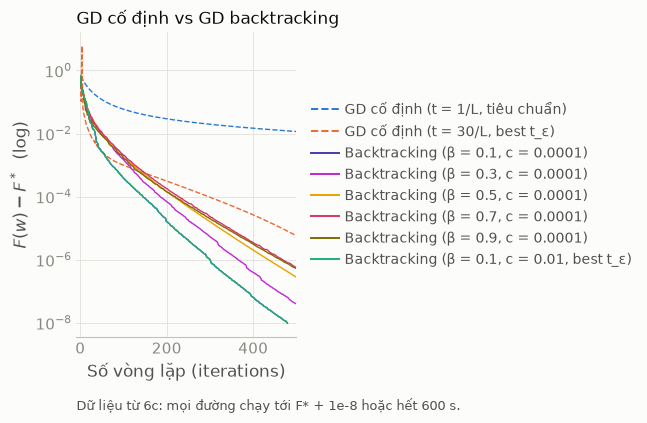

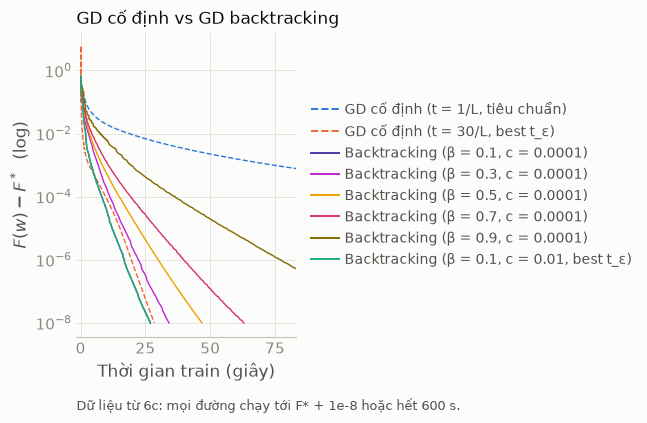

In [23]:
# ===== So sanh: GD buoc co dinh (tieu chuan + best) vs GD backtracking (du lieu 6c) =====
X_CAT = 500                                           # truc vong cat o ~500 vong (khong cat du lieu)
giay_tai = lambda ds, k: max(t[min(k, len(t) - 1)] for _, _, t in ds)   # giay tai vong k cua duong cham nhat
gd_tc, = lay_6c(("GD cố định", "t=1/L"))
gd_best, _ = best_6c([x for x in KQ_6C if x[0] == "GD cố định"])
bt_best, _ = best_6c([x for x in KQ_6C if x[0] == "GD backtracking"])
bt = lay_6c(*[("GD backtracking", "β=%g c=0.0001" % b) for b in BETA])
if bt_best[1] not in [x[1] for x in bt]:
    bt.append(bt_best)
nhan = lambda x, them="": "%s (%s%s%s)" % ("GD cố định" if x[0] == "GD cố định" else "Backtracking", ten_setup(x[1]),
                                           them, ", best t_ε" if x[1] in (gd_best[1], bt_best[1]) else "")
ss = [(nhan(gd_tc, ", tiêu chuẩn"),) + tuple(gd_tc[3]), (nhan(gd_best),) + tuple(gd_best[3])] \
     + [(nhan(x),) + tuple(x[3]) for x in bt]
kieu = dict(net=["--", "--"] + ["-"] * len(bt), F_sao=F_SAO_R, ghi_chu=GHI_6C, tieu_de="GD cố định vs GD backtracking")
ve(ss, theo_thoi_gian=False, x_max=X_CAT, luu="ss_gd_bt_vonglap.pdf", **kieu)
ve(ss, theo_thoi_gian=True, x_max=giay_tai(ss, X_CAT), luu="ss_gd_bt_thoigian.pdf", **kieu)


### So sánh: GD bước cố định và Nesterov cùng độ dài bước

Mỗi màu một độ dài bước; **nét đứt = GD, nét liền = Nesterov**. Ngoài ba bước nhỏ, hình vẽ bước best theo $t_\varepsilon$ (6c) của GD và của Nesterov; bước best nào không có setup cùng bước ở thuật toán kia (GD $30/L$: Nesterov đã không hội tụ từ $24/L$) thì vẽ riêng một nét. Hai nét cùng màu dùng **cùng thông
tin** (cùng $L$, cùng bước), nên khoảng cách giữa chúng là đúng phần tăng tốc của momentum. Thời
gian của Nesterov **không tính** gradient tại $w$ (chỉ dùng để ghi $F$ và kiểm tra điều kiện dừng),
nên mỗi vòng tốn 1 gradient như GD.

Cặp cùng bước (×1/L): 0.5, 1, 2, 6 | vẽ riêng: GD cố định 30/L   | best t_ε: GD 30/L, Nesterov 6/L


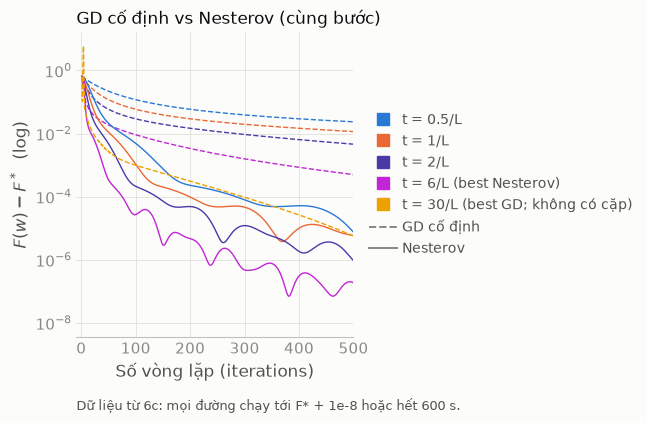

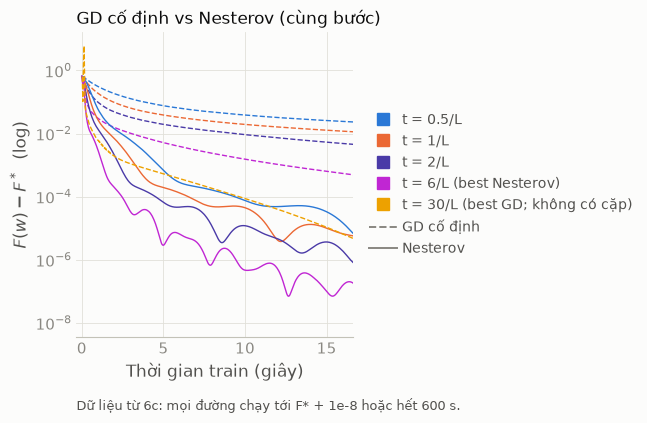

In [24]:
# ===== So sanh: GD co dinh vs Nesterov, tung cap cung buoc (du lieu 6c) =====
# 3 buoc nho + buoc best theo t_eps cua GD va cua Nesterov (doc tu 6c, tu cap nhat khi luoi doi)
buoc_best = lambda tt: float(best_6c([x for x in KQ_6C if x[0] == tt])[0][1][2:-2])     # "t=6/L" -> 6.0
B_GD, B_NES = buoc_best("GD cố định"), buoc_best("Nesterov")
# Cap CUNG buoc chi khi CA HAI thuat toan co setup o buoc do. Buoc best khong co cap (vd GD 30/L: Nesterov
# da khong hoi tu tu 24/L, khong chay 30/L) -> ve RIENG mot net, mau ke tiep.
co_6c = {(x[0], x[1]) for x in KQ_6C}
co_ca_hai = lambda k: all((tt, "t=%g/L" % k) in co_6c for tt in ["GD cố định", "Nesterov"])
K_SS = sorted(k for k in set([0.5, 1, 2, B_GD, B_NES]) if co_ca_hai(k))
LE = [(tt, b) for tt, b in [("GD cố định", B_GD), ("Nesterov", B_NES)] if b not in K_SS]
print("Cặp cùng bước (×1/L):", ", ".join("%g" % k for k in K_SS),
      "| vẽ riêng:", ", ".join("%s %g/L" % le for le in LE) or "không",
      "  | best t_ε: GD %g/L, Nesterov %g/L" % (B_GD, B_NES))
nhan_k = lambda k: "t = %g/L" % k + ("" if k not in (B_GD, B_NES) else
                   " (best %s)" % " & ".join(n for n, b in [("GD", B_GD), ("Nesterov", B_NES)] if b == k))
ss = [(x[1],) + tuple(x[3]) for x in lay_6c(*[("GD cố định", "t=%g/L" % k) for k in K_SS]
                                             + [("Nesterov", "t=%g/L" % k) for k in K_SS] + [(tt, "t=%g/L" % b) for tt, b in LE])]
mau_le = MAU[len(K_SS):len(K_SS) + len(LE)]
kieu = dict(mau=MAU[:len(K_SS)] * 2 + mau_le,
            net=["--"] * len(K_SS) + ["-"] * len(K_SS) + ["--" if tt == "GD cố định" else "-" for tt, _ in LE],
            F_sao=F_SAO_R, ghi_chu=GHI_6C,
            chu=[(nhan_k(k), c) for k, c in zip(K_SS, MAU)]
                + [("t = %g/L (best %s; không có cặp)" % (b, "GD" if tt == "GD cố định" else tt), c)
                   for (tt, b), c in zip(LE, mau_le)]
                + [("GD cố định", MO, "--", None), ("Nesterov", MO, "-", None)],
            tieu_de="GD cố định vs Nesterov (cùng bước)")
ve(ss, theo_thoi_gian=False, x_max=X_CAT, luu="ss_gd_nesterov_vonglap.pdf", **kieu)
ve(ss, theo_thoi_gian=True, x_max=giay_tai(ss, X_CAT), luu="ss_gd_nesterov_thoigian.pdf", **kieu)


### So sánh: Newton bước cố định và Newton backtracking trên cùng một hình

**Nét đứt + chấm tròn** = bước cố định $t$; **nét liền + dấu ×** = backtracking với từng $\beta$;
**nét chấm** = Nesterov tốt nhất theo $t_\varepsilon$ (6c) làm mốc: hội tụ bậc hai đặt cạnh hội tụ tuyến tính tốt nhất của
nhóm bậc nhất. Trục số vòng dùng thang log vì Newton chỉ chạy vài vòng còn Nesterov hàng trăm.

Mọi $\beta$ cho đường **trùng hẳn** bước cố định $t=1$ (ô dưới tự kiểm tra): hàm log-loss đủ trơn
và bước Newton đủ chính xác nên $t=1$ thoả Armijo **ngay từ vòng đầu**, vòng `while` không bao giờ
phải co bước — $\beta$ không có dịp ảnh hưởng.

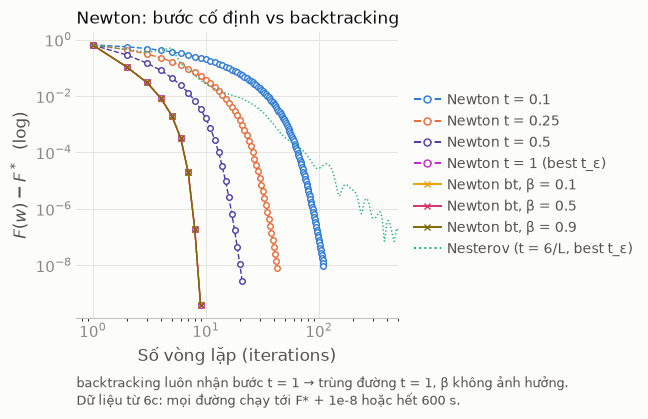

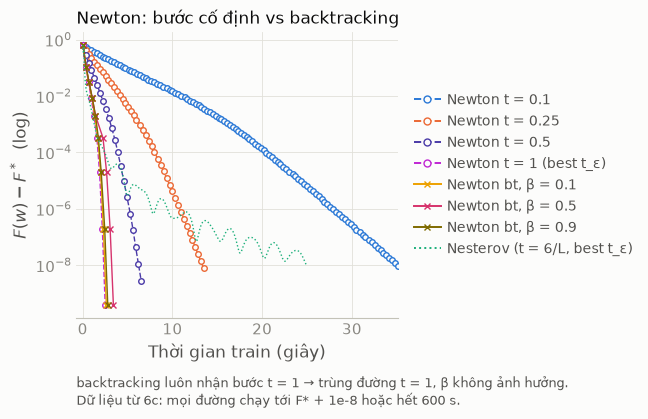

Backtracking trùng hẳn bước cố định t = 1: True


In [25]:
# ===== So sanh: Newton co dinh + Newton backtracking + Nesterov best (moc) (du lieu 6c) =====
nt = lay_6c(*[("Newton", "t=%g" % b) for b in BUOC_NT] + [("Newton", "bt β=%g" % b) for b in BETA_NT])
acc_best, _ = best_6c([x for x in KQ_6C if x[0] == "Nesterov"])
F_t1 = nt[BUOC_NT.index(1.0)][3][0]
trung = all(len(x[3][0]) == len(F_t1) and np.allclose(x[3][0], F_t1) for x in nt[len(BUOC_NT):])
nt_best, _ = best_6c([x for x in KQ_6C if x[0] == "Newton"])
ss = ([("Newton " + ten_setup(x[1]) + (" (best t_ε)" if x[1] == nt_best[1] else ""),) + tuple(x[3]) for x in nt]
      + [("Nesterov (%s, best t_ε)" % ten_setup(acc_best[1]),) + tuple(acc_best[3])])
kieu = dict(net=["--"] * len(BUOC_NT) + ["-"] * len(BETA_NT) + [":"],
            dau=["o"] * len(BUOC_NT) + ["x"] * len(BETA_NT) + [None],
            F_sao=F_SAO_R, tieu_de="Newton: bước cố định vs backtracking",
            ghi_chu=("backtracking luôn nhận bước t = 1 → trùng đường t = 1, β không ảnh hưởng.\n" if trung else "")
                    + GHI_6C)
ve(ss, theo_thoi_gian=False, log_x=True, x_max=X_CAT, luu="ss_newton_vonglap.pdf", **kieu)
ve(ss, theo_thoi_gian=True, x_max=giay_tai(ss, X_CAT), luu="ss_newton_thoigian.pdf", **kieu)
print("Backtracking trùng hẳn bước cố định t = 1:", trung)


### So sánh: SGD và GD trên cùng trục "số lượt qua dữ liệu"

1 epoch SGD = 1 vòng GD = 1 vòng Nesterov = **1 lượt đọc hết dữ liệu** (Nesterov không tính gradient
dùng để kiểm tra dừng). Mỗi lịch giảm bước lấy setup (batch, $\alpha_0$)
có $t_\varepsilon$ nhỏ nhất ở 6c (lịch $1/k$ không có trong lưới 6c nên không vẽ); GD và Nesterov lấy best theo
$t_\varepsilon$. Đường SGD là $F$ trên **toàn bộ** dữ liệu cuối mỗi epoch. Nét liền = SGD, nét đứt = mốc GD.

Trục "số lượt" đo chi phí theo **số phép tính**; hình theo thời gian đặt cạnh cho thấy chi phí thật
trên máy này — một epoch SGD đắt hơn một vòng GD nhiều lần (dòng in ở dưới), chủ yếu do bước lấy
mini-batch `X[idx]` phải chép dữ liệu.


Setup trên hình: best theo t_ε (SGD: best riêng từng lịch, trên mọi batch × α0)
Đường                               ε     giây tới ε  lượt tới ε
----------------------------------  ----  ----------  ----------
SGD (B = 16384, cố định, α0 = 0.2)  1e-6  298.0       373       
SGD (B = 4096, 1/√k, α0 = 1)        1e-6  111.5       120       
GD cố định (t = 30/L)               1e-6  19.6        600       
Nesterov (t = 6/L)                  1e-6  7.7         230       


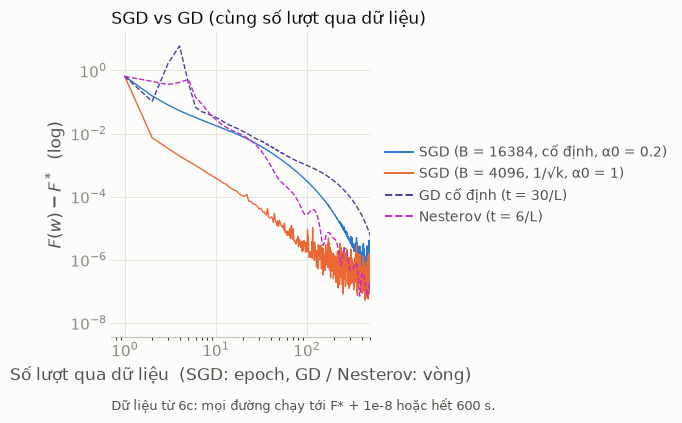

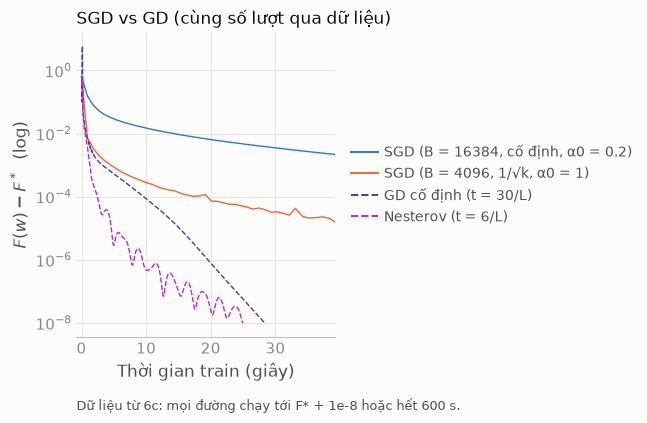

1 epoch SGD = 0.815 giây, 1 vòng GD = 0.0332 giây  ->  1 epoch ≈ 25 vòng GD   (trung vị, bảng chi phí ở 6c)


In [26]:
# ===== So sanh: SGD (best tung lich) vs GD co dinh vs Nesterov, cung so luot qua du lieu (du lieu 6c) =====
chon_ss = ([best_6c([x for x in KQ_6C if x[0] == "SGD" and " %s " % l in x[1]]) for l in LICH_SGD]
           + [best_6c([x for x in KQ_6C if x[0] == tt]) for tt in ["GD cố định", "Nesterov"]])
in_bang(["Đường", "ε", "giây tới ε", "lượt tới ε"],
        [[nhan_6c(x), so_e(e), "%.1f" % toi(x, e)[1], "%d" % toi(x, e)[0]] for x, e in chon_ss],
        "Setup trên hình: best theo t_ε (SGD: best riêng từng lịch, trên mọi batch × α0)")
ss = [(nhan_6c(x),) + tuple(x[3]) for x, _ in chon_ss]
so_sgd = len(LICH_SGD)
kieu = dict(net=["-"] * so_sgd + ["--", "--"], F_sao=F_SAO_R, ghi_chu=GHI_6C,
            tieu_de="SGD vs GD (cùng số lượt qua dữ liệu)")
ve(ss, theo_thoi_gian=False, log_x=True, x_max=X_CAT, luu="ss_sgd_gd_luot.pdf",
   ten_x="Số lượt qua dữ liệu  (SGD: epoch, GD / Nesterov: vòng)", **kieu)
# hinh thoi gian: SGD toi EPOCH epoch, GD / Nesterov toi X_CAT vong — tuong duong hinh cu
ve(ss, theo_thoi_gian=True, x_max=max(giay_tai(ss[:so_sgd], EPOCH), giay_tai(ss[so_sgd:], X_CAT)),
   luu="ss_sgd_gd_thoigian.pdf", **kieu)

print("1 epoch SGD = %.3f giây, 1 vòng GD = %.4f giây  ->  1 epoch ≈ %.0f vòng GD   (trung vị, bảng chi phí ở 6c)"
      % (giay_vong["SGD"], giay_vong["GD cố định"], giay_vong["SGD"] / giay_vong["GD cố định"]))


### So sánh: ISTA và FISTA cùng độ dài bước, mốc subgradient

Mỗi màu một độ dài bước; **nét đứt = ISTA, nét liền = FISTA**; ngoài ba bước nhỏ, hình vẽ thêm bước best theo $t_arepsilon$ (6c) của ISTA và của FISTA (ô in ra); nét chấm là subgradient tốt nhất
theo $t_\varepsilon$ (6c) — mốc cho thấy tách riêng phần trơn / không trơn lợi đến đâu.

Bước trên hình (×1/L): 0.5, 1, 2, 19, 32   | best t_ε: ISTA 19/L, FISTA 32/L
Mốc subgradient: Subgradient (α0 = 30), best theo t_ε ở ε = 1e-5 (379.3 giây); không setup nào tới ε = 1e-6 trong 600 giây


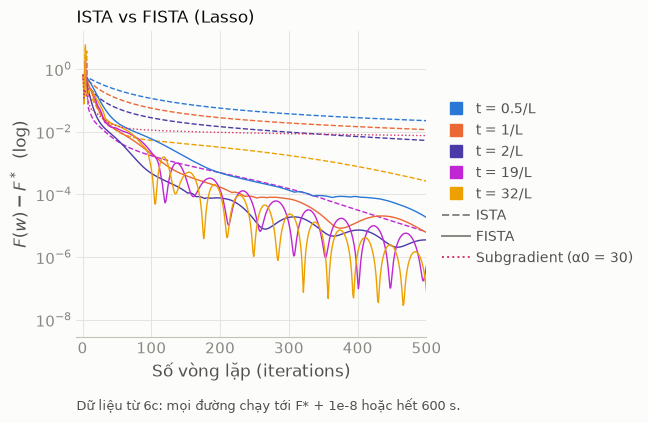

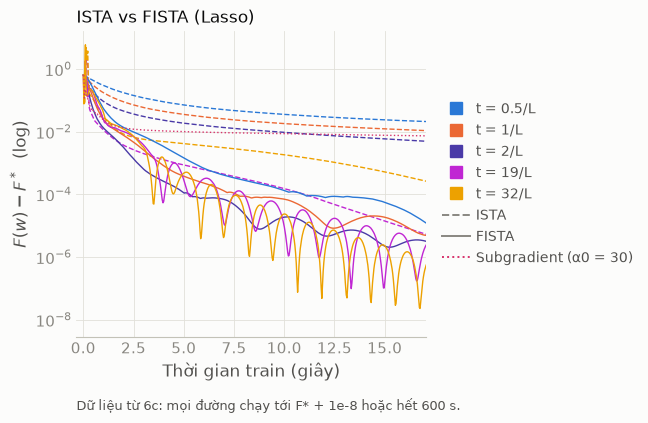

In [27]:
# ===== So sanh: ISTA vs FISTA cung buoc + subgradient tot nhat (theo t_eps) lam moc (du lieu 6c) =====
# 3 buoc nho + buoc best theo t_eps cua ISTA va cua FISTA (doc tu 6c, tu cap nhat khi luoi doi)
buoc_best = lambda tt: float(best_6c([x for x in KQ_6C if x[0] == tt])[0][1][2:-2])     # "t=6/L" -> 6.0
K_SS = sorted(set([0.5, 1, 2, buoc_best("ISTA"), buoc_best("FISTA")]))
print("Bước trên hình (×1/L):", ", ".join("%g" % k for k in K_SS),
      "  | best t_ε: ISTA %g/L, FISTA %g/L" % (buoc_best("ISTA"), buoc_best("FISTA")))
sg, e_sg = best_6c([x for x in KQ_6C if x[0] == "Subgradient"])
print("Mốc subgradient: %s, best theo t_ε ở ε = %s (%.1f giây)%s"
      % (nhan_6c(sg), so_e(e_sg), toi(sg, e_sg)[1],
         "" if e_sg == EPS_CHINH else "; không setup nào tới ε = %s trong %d giây" % (so_e(EPS_CHINH), TRAN)))
ss = ([(x[1],) + tuple(x[3]) for x in lay_6c(*[("ISTA", "t=%g/L" % k) for k in K_SS]
                                              + [("FISTA", "t=%g/L" % k) for k in K_SS])]
      + [(nhan_6c(sg),) + tuple(sg[3])])
kieu = dict(mau=MAU[:len(K_SS)] * 2 + [MAU[len(K_SS)]], net=["--"] * len(K_SS) + ["-"] * len(K_SS) + [":"],
            chu=[("t = %g/L" % k, c) for k, c in zip(K_SS, MAU)]
                + [("ISTA", MO, "--", None), ("FISTA", MO, "-", None), (nhan_6c(sg), MAU[len(K_SS)], ":", None)],
            F_sao=F_SAO_L_CX, ghi_chu=GHI_6C, tieu_de="ISTA vs FISTA (Lasso)")
ve(ss, theo_thoi_gian=False, x_max=X_CAT, luu="ss_ista_fista_vonglap.pdf", **kieu)
ve(ss, theo_thoi_gian=True, x_max=giay_tai(ss, X_CAT), luu="ss_ista_fista_thoigian.pdf", **kieu)


---
## 6e. Tổng kết: setup tốt nhất của từng thuật toán so với thư viện

Mỗi thuật toán lấy **setup tốt nhất theo $t_\varepsilon$** ở $\varepsilon=10^{-6}$ (`EPS_CHINH`, thống nhất
với mục 7): trong lưới đầy đủ của 6c, setup tới $F-F^\star\le10^{-6}$ **nhanh nhất theo giây**. Best ở
$10^{-5}$ và $10^{-6}$ trùng nhau. Đường $(F,t)$ lấy thẳng từ `KQ_6C` (không chạy lại); mọi đường chạy tới
$F^\star+10^{-8}$ hoặc hết 600 giây. So **giá trị hàm mục tiêu** và **thời gian tính**, đúng yêu cầu đề bài.
Trục hoành dùng thang log (Newton chỉ cần vài vòng, GD hàng nghìn vòng) và cắt ở lúc đường chậm nhất
đạt $10^{-7}$; đường chấm xám là mức $\varepsilon=10^{-6}$.

Điều kiện để so được: các đường phải tối thiểu hoá **cùng một hàm** $F$. GD bước cố định,
GD backtracking, GD Nesterov, Newton và SGD đều giải bài toán Ridge với cùng $\lambda$ nên nằm chung
một hình.

**Setting của 5 setup tốt nhất** (chung: $\lambda=10^{-3}$, $w_0=0$, $L=6{,}25$; bảng in ở ô dưới là
nguồn chính xác):

- GD bước cố định: $t=30/L$ (sát cận ổn định $2/\lambda_{\max}(H)\approx32/L$; $34/L$ không hội tụ)
- GD backtracking: $\beta=0{,}1$, $c=10^{-2}$, mỗi vòng thử bước gấp đôi bước trước ($c=10^{-4}$ cùng
  300 vòng, chỉ chậm hơn 0,07 giây)
- Nesterov: $t=6/L$, không restart ($8/L$ nhanh hơn ở $\varepsilon=10^{-3}$ và $10^{-5}$, chậm hơn ở $10^{-6}$)
- Newton: $t=1$ (backtracking cho kết quả trùng hẳn)
- SGD: batch 4096, lịch $\alpha_k=\alpha_0/\sqrt k$, $\alpha_0=1$ — so bằng $F$ trên toàn bộ dữ liệu cuối mỗi epoch
- sklearn: `lbfgs` mặc định, $C=1/(n\lambda)$, **đo lại ngay trong ô vẽ**; trên hình theo thời gian là
  **một điểm** (giây, $F$)

**Nguồn gốc số liệu thời gian** (tien_trinh.md, mục 23.2): GD cố định, GD backtracking và Nesterov đo bằng
`chay_6c_rieng.py` (tiến trình riêng ngoài notebook); Newton lấy từ lần chạy lại trong notebook lúc 10:58
ngày 08/10/2026; SGD, subgradient, ISTA, FISTA lấy từ lần chạy đầy đủ, riêng các bước lớn chạy bổ sung bằng
`chay_6c_rieng.py` ngày 09/10/2026: ISTA $6/L$ (01:47), ISTA/FISTA $19$–$48/L$ (02:07), $64$–$128/L$ (09:30),
Nesterov $8$–$24/L$ và GD $12$–$34/L$ (21:28). Thời gian đo có thể lệch tới khoảng
50% giữa các lần chạy, nên bảng in kèm **số vòng** tới $\varepsilon$. Ở $\varepsilon=10^{-3}$ các phương
pháp đứng đầu (Nesterov 1,3 giây, Newton 1,6 giây, SGD 1,6 giây) chênh nhau trong biên độ nhiễu đo thời
gian, nên không xếp hạng được ở mức đó.

**Subgradient, ISTA và FISTA thì không**, vì cả hai giải Lasso — hàm mục tiêu khác hẳn
($\lambda_1\|w\|_1$ thay cho $\tfrac{\lambda}{2}\|w\|_2^2$). Đặt chung một trục là so sai.
Chúng có bảng và hình so riêng với nhau (best cũng theo
$t_\varepsilon$; subgradient không setup nào tới $10^{-6}$ trong 600 giây nên lấy best ở $\varepsilon$ nhỏ nhất
đạt được) và với `LogisticRegression` L1 (`solver="saga"`) ở dưới.

Quy đổi tham số để sklearn tối thiểu hoá đúng $F$ của mình: sklearn dùng
$\tfrac12\|w\|^2 + C\sum_i\ell_i$ (tổng), mình dùng $\tfrac1n\sum_i\ell_i+\tfrac{\lambda}{2}\|w\|^2$
(trung bình), nên $C=\dfrac{1}{n\lambda}$.


Ridge: best theo thời gian tới F − F* ≤ 1e-6  (SGD: vòng = epoch; sklearn: số vòng, giây của cả lần fit)
Thuật toán       Setup (best theo t_ε)   ε          Vòng tới ε  giây tới ε  F − F* min  Tổng vòng  Tổng giây
---------------  ----------------------  ---------  ----------  ----------  ----------  ---------  ---------
GD cố định       t = 30/L                1e-6       600         19.56       9.9e-09     870        28.3     
GD backtracking  β = 0.1, c = 0.01       1e-6       300         16.82       9.7e-09     478        26.8     
Nesterov         t = 6/L                 1e-6       230         7.65        9.8e-09     750        25.0     
Newton           t = 1                   1e-6       7           2.19        3.9e-10     8          2.5      
SGD              B = 4096, 1/√k, α0 = 1  1e-6       120         111.53      3.9e-08     649        600.7    
sklearn          lbfgs mặc định          tol riêng  27          1.25        9.1e-06     -          -        


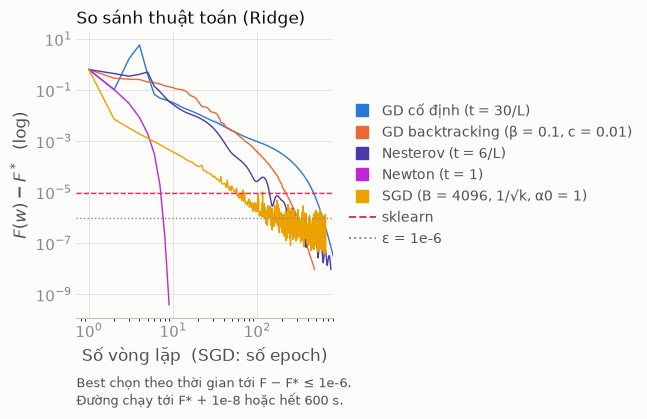

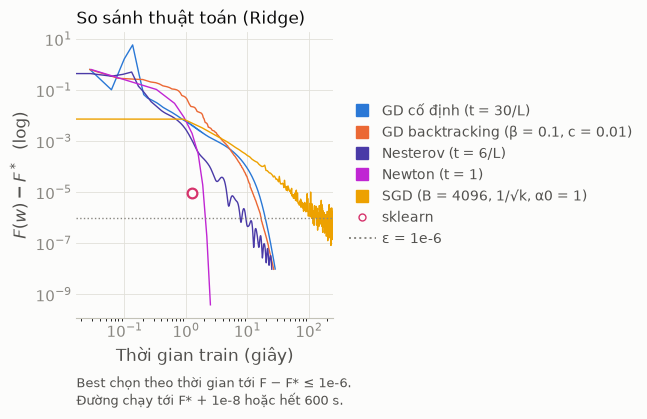

In [28]:
# ===== Ridge: best cua tung thuat toan theo t_eps (du lieu 6c) + sklearn =====
# Best = setup toi F - F* <= EPS_CHINH nhanh nhat (best_6c, o 6c). Duong (F, t) lay thang tu KQ_6C.
TT_RIDGE = ["GD cố định", "GD backtracking", "Nesterov", "Newton", "SGD"]
TOP_R = [best_6c([x for x in KQ_6C if x[0] == tt]) for tt in TT_RIDGE]      # (dong KQ_6C, eps da dung)

# sklearn do lai trong CUNG o (cung dieu kien may voi luc ve hinh)
t0 = time.time()
sk = LogisticRegression(C=1 / (n * LAM)).fit(X_tr[:, 1:], y_tr)
gio_sk = time.time() - t0
F_sk = ridge(np.r_[sk.intercept_, sk.coef_[0]], X_tr, y_tr, LAM)[0]

COT_BEST = ["Thuật toán", "Setup (best theo t_ε)", "ε", "Vòng tới ε", "giây tới ε", "F − F* min",
            "Tổng vòng", "Tổng giây"]


def hang_best(x, e, F_sao):
    (v, g), (F, t) = toi(x, e), x[3]
    return [x[0], ten_setup(x[1]), so_e(e), "%d" % v, "%.2f" % g, "%.1e" % (np.min(F) - F_sao),
            "%d" % (len(F) - 1), "%.1f" % t[-1]]


in_bang(COT_BEST, [hang_best(x, e, F_SAO_R) for x, e in TOP_R]
        + [["sklearn", "lbfgs mặc định", "tol riêng", "%d" % sk.n_iter_[0], "%.2f" % gio_sk,
            "%.1e" % (F_sk - F_SAO_R), "-", "-"]],
        "Ridge: best theo thời gian tới F − F* ≤ %s  (SGD: vòng = epoch; sklearn: số vòng, giây của cả lần fit)"
        % so_e(EPS_CHINH))

GHI_TONG = "Best chọn theo thời gian tới F − F* ≤ %s.\nĐường chạy tới F* + 1e-8 hoặc hết %d s." % (so_e(EPS_CHINH), TRAN)
duong_top = [(nhan_6c(x),) + tuple(x[3]) for x, _ in TOP_R]
kieu = dict(moc=(F_sk, gio_sk), F_sao=F_SAO_R, log_x=True, ngang=(EPS_CHINH, "ε = %s" % so_e(EPS_CHINH)),
            ghi_chu=GHI_TONG, tieu_de="So sánh thuật toán (Ridge)")
ve(duong_top, theo_thoi_gian=False, x_max=x_toi([x for x, _ in TOP_R], thoi_gian=False),
   ten_x="Số vòng lặp  (SGD: số epoch)", luu="tongket_vonglap.pdf", **kieu)
ve(duong_top, theo_thoi_gian=True, x_max=x_toi([x for x, _ in TOP_R]), luu="tongket_thoigian.pdf", **kieu)


c:\repos\baauf-do\santander-product-recommendation\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Lasso: best theo thời gian tới F − F* ≤ 1e-6 (không setup nào đạt -> ε nhỏ nhất đạt được); số hệ số ≠ 0 ở bảng log-loss dưới
Thuật toán   Setup (best theo t_ε)  ε          Vòng tới ε  giây tới ε  F − F* min  Tổng vòng  Tổng giây
-----------  ---------------------  ---------  ----------  ----------  ----------  ---------  ---------
Subgradient  α0 = 30                1e-5       11734       379.27      6.3e-06     18563      600.0    
ISTA         t = 19/L               1e-6       626         20.94       1.0e-08     1923       64.4     
FISTA        t = 32/L               1e-6       282         9.40        8.6e-09     574        19.2     
sklearn      saga, L1               tol riêng  100         54.37       8.4e-07     -          -        


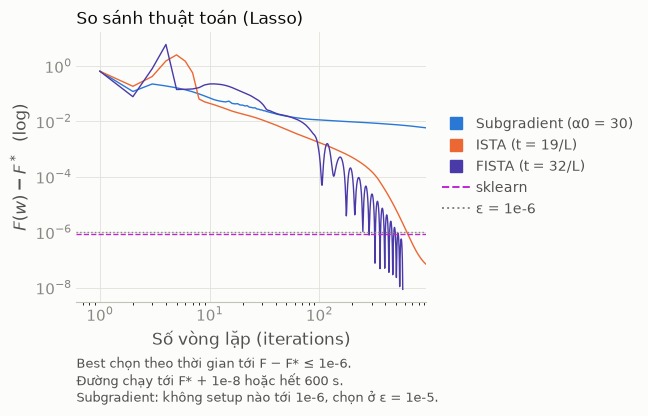

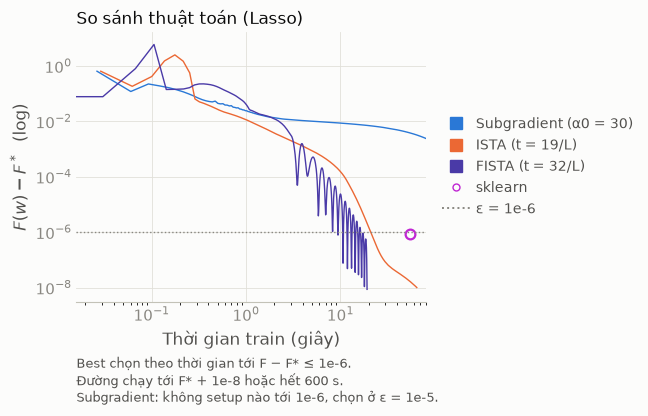

In [29]:
# ===== Lasso: subgradient vs ISTA vs FISTA (best theo t_eps, du lieu 6c) + sklearn L1 =====
# Ham muc tieu KHAC Ridge nen de rieng.
# saga (khong phai liblinear): liblinear PHAT CA intercept nen giai mot bai toan khac; saga khong phat.
# l1_ratio=1 = L1 thuan (cach viet moi thay penalty="l1" tu sklearn 1.8). random_state co dinh cho lap lai duoc.
t0 = time.time()
sk1 = LogisticRegression(l1_ratio=1, C=1 / (n * LAM1), solver="saga", random_state=0).fit(X_tr[:, 1:], y_tr)
gio_sk1 = time.time() - t0
w_sk1 = np.r_[sk1.intercept_, sk1.coef_[0]]
F_sk1 = lasso(w_sk1, X_tr, y_tr, LAM1)[0]
if F_sk1 < F_SAO_L_CX:
    print("CANH BAO: sklearn saga cho F = %.12f < F* Lasso cua 6c (%.12f)" % (F_sk1, F_SAO_L_CX))

TT_LASSO = ["Subgradient", "ISTA", "FISTA"]
TOP_L = [best_6c([x for x in KQ_6C if x[0] == tt]) for tt in TT_LASSO]
in_bang(COT_BEST, [hang_best(x, e, F_SAO_L_CX) for x, e in TOP_L]
        + [["sklearn", "saga, L1", "tol riêng", "%d" % np.max(sk1.n_iter_), "%.2f" % gio_sk1,
            "%.1e" % (F_sk1 - F_SAO_L_CX), "-", "-"]],
        "Lasso: best theo thời gian tới F − F* ≤ %s (không setup nào đạt -> ε nhỏ nhất đạt được); "
        "số hệ số ≠ 0 ở bảng log-loss dưới" % so_e(EPS_CHINH))

lui = ["%s: không setup nào tới %s, chọn ở ε = %s." % (x[0], so_e(EPS_CHINH), so_e(e)) for x, e in TOP_L if e != EPS_CHINH]
duong_lasso = [(nhan_6c(x),) + tuple(x[3]) for x, _ in TOP_L]
kieu = dict(moc=(F_sk1, gio_sk1), F_sao=F_SAO_L_CX, log_x=True, ngang=(EPS_CHINH, "ε = %s" % so_e(EPS_CHINH)),
            ghi_chu="\n".join([GHI_TONG] + lui), tieu_de="So sánh thuật toán (Lasso)")
ve(duong_lasso, theo_thoi_gian=False, x_max=x_toi([x for x, _ in TOP_L], thoi_gian=False),
   luu="lasso_vonglap.pdf", **kieu)
ve(duong_lasso, theo_thoi_gian=True, x_max=x_toi([x for x, _ in TOP_L]), luu="lasso_thoigian.pdf", **kieu)


In [30]:
# ===== Log-loss (KHONG cong phat) tren train / validation cua setup best (theo t_eps) =====
# Cac gia tri chi chenh nhau o chu so thu 3-4 nen in BANG, khong ve. KQ_6C chi giu (F, t), nen chay lai
# DUNG setup best (cung tham so, cung seed) toi khi F - F* <= eps da dung de chon best -> lay w.
import re


def log_loss(w, X, y):
    z = X @ w
    return np.mean(np.logaddexp(0, z) - y * z)


def w_6c(x, eps):
    """Chay lai DUNG setup x cua KQ_6C toi khi F - F* <= eps (hoac het TRAN giay) -> w."""
    tt, setup, bt = x[:3]
    p = dict(re.findall(r"(\S+)=(\S+)", setup))        # vd {"t": "6/L"}, {"β": "0.1", "c": "0.01"}, {"B": "4096", "α0": "1"}
    dung = dict(max_vong_lap=VO_HAN, tol=TOL_THU, max_giay=TRAN,
                F_dung=(F_SAO_R if bt == "Ridge" else F_SAO_L_CX) + eps)
    buoc = lambda: float(p["t"].split("/")[0]) / (L0 if p["t"].endswith("/L") else 1)
    if tt == "GD cố định":
        return gradient_descent(X_tr, y_tr, LAM, buoc(), **dung)[0]
    if tt == "GD backtracking":
        return gradient_descent_bt(X_tr, y_tr, LAM, beta=float(p["β"]), c=float(p["c"]), **dung)[0]
    if tt == "Nesterov":
        return gd_nesterov(X_tr, y_tr, LAM, buoc(), **dung)[0]
    if tt == "Newton":
        return (newton(X_tr, y_tr, LAM, buoc(), **dung) if "t" in p else
                newton(X_tr, y_tr, LAM, backtracking=True, beta=float(p["β"]), **dung))[0]
    if tt == "SGD":
        return sgd(X_tr, y_tr, LAM, float(p["α0"]), batch=int(p["B"]),
                   lich="1/sqrt" if "1/sqrt" in setup else "co dinh", **dung)[0]
    if tt == "Subgradient":
        return subgradient(X_tr, y_tr, LAM1, float(p["α0"]), **dung)[0]
    return proximal_gradient(X_tr, y_tr, LAM1, buoc(), gia_toc=(tt == "FISTA"), **dung)[0]


W_TOT = []          # (phuong phap, bai toan, setup, eps dung, w, giay chay lai / giay fit)
for x, e in TOP_R + TOP_L:
    t0 = time.time()
    W_TOT.append((x[0], x[2], ten_setup(x[1]), so_e(e), w_6c(x, e), time.time() - t0))
W_TOT.insert(len(TOP_R), ("sklearn lbfgs", "Ridge", "mặc định", "-", np.r_[sk.intercept_, sk.coef_[0]], gio_sk))
W_TOT.append(("sklearn saga", "Lasso", "L1", "-", w_sk1, gio_sk1))
F_tru_sao = lambda b, w: (ridge(w, X_tr, y_tr, LAM)[0] - F_SAO_R if b == "Ridge"
                          else lasso(w, X_tr, y_tr, LAM1)[0] - F_SAO_L_CX)
in_bang(["Phương pháp", "Bài", "Setup", "Dừng ở ε", "F − F*", "log-loss train", "log-loss val", "Hệ số ≠ 0", "giây"],
        [[p, b, s, e, "%.1e" % F_tru_sao(b, w), "%.6f" % log_loss(w, X_tr, y_tr), "%.6f" % log_loss(w, X_va, y_va),
          "%d/%d" % (np.sum(w[1:] != 0), d - 1), "%.1f" % g] for p, b, s, e, w, g in W_TOT],
        "Log-loss KHÔNG cộng phạt của setup best (train: 2015-06 → 2015-12, val: 2016-01; "
        "giây = thời gian chạy lại / fit)")



Log-loss KHÔNG cộng phạt của setup best (train: 2015-06 → 2015-12, val: 2016-01; giây = thời gian chạy lại / fit)
Phương pháp      Bài    Setup                   Dừng ở ε  F − F*   log-loss train  log-loss val  Hệ số ≠ 0  giây 
---------------  -----  ----------------------  --------  -------  --------------  ------------  ---------  -----
GD cố định       Ridge  t = 30/L                1e-6      9.9e-07  0.040564        0.036146      154/160    19.4 
GD backtracking  Ridge  β = 0.1, c = 0.01       1e-6      9.3e-07  0.040621        0.036204      154/160    16.3 
Nesterov         Ridge  t = 6/L                 1e-6      9.6e-07  0.040613        0.036194      154/160    14.8 
Newton           Ridge  t = 1                   1e-6      1.9e-07  0.040591        0.036173      154/160    2.3  
SGD              Ridge  B = 4096, 1/√k, α0 = 1  1e-6      9.6e-07  0.040607        0.036196      154/160    93.8 
sklearn lbfgs    Ridge  mặc định                -         9.1e-06  0.040654        0.03

### Thí nghiệm: thay đổi $\lambda$ — kiểm chứng lý thuyết về số điều kiện

$\lambda$ nhỏ đi thì số điều kiện $\kappa$ lớn lên. Lý thuyết dự đoán số vòng của **GD tăng theo
$\kappa$**, của **Nesterov theo $\sqrt\kappa$**, còn **Newton gần như không đổi**: giảm $\lambda$ 10 lần
thì số vòng GD tăng ~10 lần, Nesterov ~3,2 lần, Newton ~1 lần.

Cách đo: đếm số vòng tới **cùng một khoảng cách tương đối**
$\dfrac{F(w_k)-F^\star}{F(w_0)-F^\star}\le10^{-6}$ — không dùng điều kiện dừng `TOL`, vì cùng một
`TOL` trên gradient ứng với $F-F^\star$ khác nhau khi $\mu$ đổi. Mỗi $\lambda$ tính lại $F^\star$ bằng
Newton (tol $10^{-10}$); GD và Nesterov dùng bước tiêu chuẩn $1/L$ với $L=L_0+\lambda$, chạy tới khi
đạt mức trên hoặc hết `TRAN_LAM` giây.

$L/\lambda$ chỉ là **cận trên** của $\kappa$ ($\mu\ge\lambda$ là cận dưới, còn $L$ là cận trên của độ
cong). Vì vậy ô dưới tính **$\kappa$ thật** từ Hessian tại nghiệm (cùng công thức Hessian mà Newton dùng):

$$\kappa=\frac{\lambda_{\max}(H)}{\lambda_{\min}(H)},\qquad
H=\nabla^2F(w^\star)=\tfrac1nX^\top\mathrm{diag}\big(\sigma_i(1-\sigma_i)\big)X+\lambda I'$$

rồi in thêm cột **số vòng Nesterov / $\sqrt\kappa$**. Nếu cột tỉ số này gần như **hằng số** khi $\lambda$
đổi thì kết luận được số vòng Nesterov tỉ lệ với $\sqrt\kappa$.


Số vòng tới (F - F*)/(F(w0) - F*) <= 1e-06   ('> N' = chưa đạt sau 120 giây; κ = λmax(H)/λmin(H) tại w*)
λ       L/λ (cận κ)  κ thật  √κ    GD 1/L  Nesterov  Nesterov / √κ  Newton
------  -----------  ------  ----  ------  --------  -------------  ------
0.01    626          96      9.8   > 3795  384       39.2           6     
0.001   6252         392     19.8  > 3732  896       45.3           7     
0.0001  62509        2986    54.6  > 3697  1247      22.8           8     

Số vòng tăng bao nhiêu lần khi λ giảm 10 lần, so với κ thật
λ               κ thật tăng  √κ tăng  GD (lý thuyết ∝ κ)  Nesterov (∝ √κ)  Newton (≈ ×1)
--------------  -----------  -------  ------------------  ---------------  -------------
0.01 → 0.001    ×4.1         ×2.0     -                   ×2.3             ×1.2         
0.001 → 0.0001  ×7.6         ×2.8     -                   ×1.4             ×1.1         


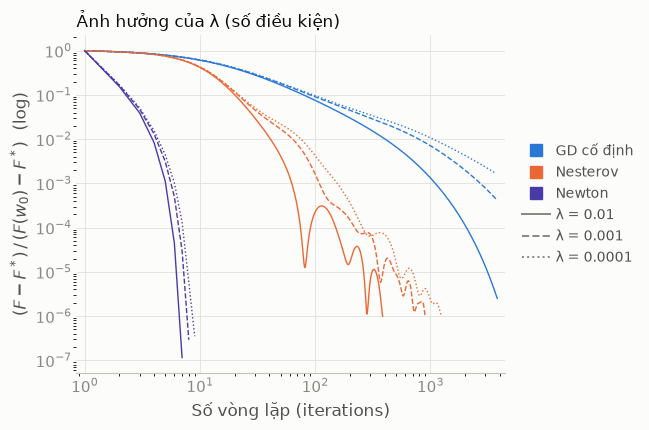

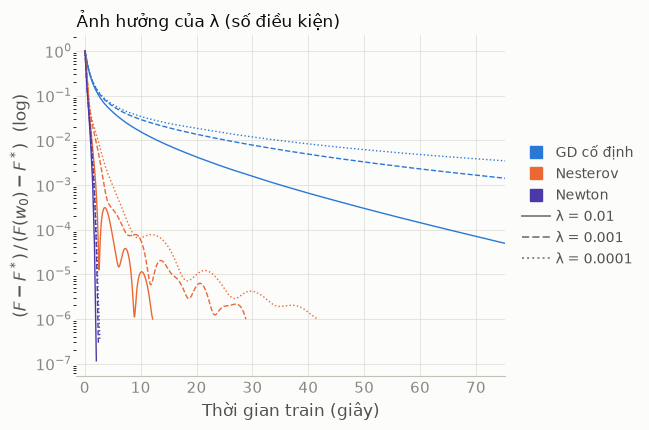

In [31]:
# ===== Thi nghiem: lambda in {1e-2, 1e-3, 1e-4} cho GD, Nesterov, Newton =====
LAM_THU = [1e-2, 1e-3, 1e-4]
NET_LAM = ["-", "--", ":"]
TT3 = ["GD cố định", "Nesterov", "Newton"]
MUC_TD = 1e-6        # khoang cach tuong doi can dat
TRAN_LAM = 120       # giay toi da moi lan chay (ca o ~ 10-15 phut)
ss, bang_lam, KAPPA = [], [], {}
for lam, ls in zip(LAM_THU, NET_LAM):
    w_sao, F_nt, _ = newton(X_tr, y_tr, lam, backtracking=True, max_vong_lap=100, tol=1e-10)
    F_sao = min(F_nt)
    # kappa THAT = lambda_max(H) / lambda_min(H), H = Hessian tai w* (cung cong thuc voi Newton)
    s = sigmoid(X_tr @ w_sao)
    H = X_tr.T @ (X_tr * (s * (1 - s))[:, None]) / n + np.diag(np.r_[0.0, np.full(d - 1, lam)])
    tri_rieng = np.linalg.eigvalsh(H)
    KAPPA[lam] = tri_rieng[-1] / tri_rieng[0]
    L = L0 + lam
    chung = dict(max_vong_lap=10**7, tol=1e-12, max_giay=TRAN_LAM,
                 F_dung=F_sao + MUC_TD * (np.log(2) - F_sao))          # F(w0 = 0) = log 2
    for tt, (F, t) in zip(TT3, [gradient_descent(X_tr, y_tr, lam, 1 / L, **chung)[1:],
                                gd_nesterov(X_tr, y_tr, lam, 1 / L, **chung)[1:],
                                newton(X_tr, y_tr, lam, backtracking=True, **chung)[1:]]):
        td = (np.asarray(F) - F_sao) / (F[0] - F_sao)
        ss.append(("%s, λ = %g" % (tt, lam), td, t))
        k = np.nonzero(td <= MUC_TD)[0]
        bang_lam.append((tt, lam, L / lam, k[0] if len(k) else np.inf, t[k[0]] if len(k) else np.inf, len(F) - 1))

vong = {(tt, lam): v for tt, lam, kap, v, g, v_max in bang_lam}
vmax = {(tt, lam): v_max for tt, lam, kap, v, g, v_max in bang_lam}
o_v = lambda tt, lam: "> %d" % vmax[tt, lam] if np.isinf(vong[tt, lam]) else "%d" % vong[tt, lam]
in_bang(["λ", "L/λ (cận κ)", "κ thật", "√κ", "GD 1/L", "Nesterov", "Nesterov / √κ", "Newton"],
        [["%g" % lam, "%.0f" % ((L0 + lam) / lam), "%.0f" % KAPPA[lam], "%.1f" % np.sqrt(KAPPA[lam]),
          o_v("GD cố định", lam), o_v("Nesterov", lam),
          "-" if np.isinf(vong["Nesterov", lam]) else "%.1f" % (vong["Nesterov", lam] / np.sqrt(KAPPA[lam])),
          o_v("Newton", lam)] for lam in LAM_THU],
        "Số vòng tới (F - F*)/(F(w0) - F*) <= %g   ('> N' = chưa đạt sau %d giây; κ = λmax(H)/λmin(H) tại w*)"
        % (MUC_TD, TRAN_LAM))
ti_le = lambda tt, i: ("-" if np.isinf(vong[tt, LAM_THU[i]]) or np.isinf(vong[tt, LAM_THU[i + 1]])
                       else "×%.1f" % (vong[tt, LAM_THU[i + 1]] / vong[tt, LAM_THU[i]]))
in_bang(["λ", "κ thật tăng", "√κ tăng", "GD (lý thuyết ∝ κ)", "Nesterov (∝ √κ)", "Newton (≈ ×1)"],
        [["%g → %g" % (LAM_THU[i], LAM_THU[i + 1]), "×%.1f" % (KAPPA[LAM_THU[i + 1]] / KAPPA[LAM_THU[i]]),
          "×%.1f" % np.sqrt(KAPPA[LAM_THU[i + 1]] / KAPPA[LAM_THU[i]]),
          ti_le("GD cố định", i), ti_le("Nesterov", i), ti_le("Newton", i)] for i in range(len(LAM_THU) - 1)],
        "Số vòng tăng bao nhiêu lần khi λ giảm 10 lần, so với κ thật")

# mau = thuat toan (theo thu tu), kieu net = lambda
kieu = dict(mau=MAU[:len(TT3)], net=[ls for ls in NET_LAM for _ in TT3], F_sao=0,
            ten_y=r"$(F-F^*)\,/\,(F(w_0)-F^*)$  (log)",
            chu=[(tt, c) for tt, c in zip(TT3, MAU)] + [("λ = %g" % lam, MO, ls, None)
                                                       for lam, ls in zip(LAM_THU, NET_LAM)],
            tieu_de="Ảnh hưởng của λ (số điều kiện)")
ve(ss, theo_thoi_gian=False, log_x=True, luu="ss_lambda_vonglap.pdf", **kieu)
ve(ss, theo_thoi_gian=True, luu="ss_lambda_thoigian.pdf", **kieu)

---
# Phần II. Mở rộng về mô hình

Hai mục dưới **không thuộc phần so sánh thuật toán tối ưu** ở trên. Chúng dùng thuật toán nhanh nhất
tìm được (Newton, mục 6c) như một công cụ để huấn luyện mô hình cho cả 24 sản phẩm, rồi đánh giá
**chất lượng dự đoán** (MAP@7) và so với mô hình của các lời giải top Kaggle (LightGBM).

---
## 7. Mở rộng: toàn bộ 24 sản phẩm — MAP@7

Từ đầu bài chỉ tối ưu cho **một** sản phẩm (`ind_recibo_ult1`, tỉ lệ mua cao nhất — dùng để
so thuật toán cho công bằng). Kaggle thật ra chấm trên **cả 24 sản phẩm** cùng lúc: mỗi
khách được xếp hạng theo xác suất mua từng sản phẩm, so với tối đa **7** sản phẩm khách
thực sự thêm mới ở tháng validation.

Cách làm: huấn luyện **24 mô hình độc lập** (1 hồi quy logistic nhị phân cho mỗi sản phẩm,
dùng chung ma trận đặc trưng `X`), mỗi mô hình dùng **thuật toán tốt nhất ở mục 6c: Newton
backtracking** trên bài toán Ridge — hội tụ sau ít vòng và nhanh nhất theo thời gian, lại không
phải dò bước cho từng sản phẩm (backtracking tự chọn bước, thử $t=1$ trước). Ghép 24 cột xác suất lại, loại sản
phẩm khách đã sở hữu ở tháng $t-1$ (không thể "thêm mới"), rồi lấy top-7 theo xác suất còn
lại.

MAP@7 báo cáo **hai kiểu**, chênh lệch nhau vì phần lớn khách không mua thêm gì trong tháng:

- trên khách **CÓ** thêm mới — đo mô hình xếp hạng tốt đến đâu khi có tín hiệu thật;
- trên **TOÀN BỘ** khách — đúng cách Kaggle chấm, nhỏ hơn nhiều vì đa số khách "thêm mới 0
  sản phẩm" vẫn được tính vào mẫu số.

In [32]:
def apk(that, top, k=7):
    """Average precision @ k cho 1 khach hang. `that` = tap san pham THAT SU them moi."""
    if len(that) == 0:
        return 0.0
    diem, trung = 0.0, 0
    for i, sp in enumerate(top[:k]):
        if sp in that:
            trung += 1
            diem += trung / (i + 1)
    return diem / min(len(that), k)


def map_at_7(P, Y, da_co, chi_khach_mua=True):
    """MAP@7. San pham da so huu o thang t-1 thi khong the "them moi" -> loai khoi xep hang.
    chi_khach_mua=True : trung binh tren khach CO them moi
                 =False: trung binh tren TOAN BO khach (cach Kaggle cham, nho hon nhieu)."""
    diem = np.where(da_co > 0, -np.inf, P)
    top = np.argsort(-diem, axis=1)[:, :7]
    hang = np.where(Y.sum(1) > 0)[0] if chi_khach_mua else np.arange(len(Y))
    tong = sum(apk(set(np.where(Y[i])[0]), list(top[i])) for i in hang)
    return tong / len(hang)

In [33]:
# ===== Thuat toan tot nhat (muc 6c): Newton backtracking tren Ridge, cho ca 24 san pham =====
nhanh_nhat = min((x for x in KQ_6C if x[2] == "Ridge"), key=lambda x: toi(x, 1e-6)[1])
print("Tới F - F* <= 1e-6 nhanh nhất ở mục 6c: %s (%s), %.2f giây"
      % (nhanh_nhat[0], nhanh_nhat[1], toi(nhanh_nhat, 1e-6)[1]))

cot_lag = [TEN.index(c + "_lag") for c in SP]
da_co = (X_va[:, cot_lag] > X_va[:, cot_lag].min(axis=0) + 1e-9).astype(int)

P = np.zeros((len(X_va), 24))
t0 = time.time()
for j, sp in enumerate(SP):
    yj = Y_tr[:, j].astype(np.float64)
    if yj.sum() < 10:                       # qua hiem thi lay thang ti le nen, khoi train
        P[:, j] = yj.mean()
        continue
    wj = newton(X_tr, yj, LAM, max_vong_lap=VONG_NT, backtracking=True)[0]
    P[:, j] = sigmoid(X_va @ wj)
gio_24 = time.time() - t0

ti_le = (Y_va.sum(1) > 0).mean()
print("\nMAP@7  (huấn luyện 24 sản phẩm hết %.1f giây)" % gio_24)
print("  trên khách CÓ thêm mới (%.2f%% số khách) = %.6f" % (ti_le * 100, map_at_7(P, Y_va, da_co, True)))
print("  trên TOÀN BỘ khách (cách Kaggle chấm)    = %.6f" % map_at_7(P, Y_va, da_co, False))

Tới F - F* <= 1e-6 nhanh nhất ở mục 6c: Newton (t=1), 2.19 giây



MAP@7  (huấn luyện 24 sản phẩm hết 42.0 giây)
  trên khách CÓ thêm mới (2.82% số khách) = 0.797596
  trên TOÀN BỘ khách (cách Kaggle chấm)    = 0.022517


---
## 8. So với mô hình của các lời giải top Kaggle (LightGBM)

Cùng dữ liệu, cùng 160 đặc trưng, cùng tháng validation — chỉ đổi **mô hình**:

| Mô hình | Mô phỏng |
|---|---|
| Phổ biến | xếp sản phẩm theo tỉ lệ thêm mới trên train — mốc sàn |
| Logistic Ridge ×24 | kết quả mục 7 (Newton backtracking) |
| LightGBM nhị phân ×24 | mỗi sản phẩm một mô hình — hướng của hạng 2 (Tom Van de Wiele, XGBoost) |
| LightGBM softmax | một mô hình đa lớp, mỗi dòng là một cặp (khách, sản phẩm thêm mới) — hướng của hạng 1 (idle_speculation) |

Tham số LightGBM đặt cố định, **không dò trên validation** để khỏi rò rỉ. Kaggle chấm trên tháng
2016-06 với bộ đặc trưng lớn hơn nhiều (hạng 1 ≈ 0.0314 private LB) nên không so trực tiếp được
với số ở đây; phép so công bằng là giữa các dòng của bảng dưới.

In [34]:
import lightgbm as lgb

P_lr = P.copy()                                    # xac suat cua 24 mo hinh logistic o muc 7
bang = [("Phổ biến", np.tile(Y_tr.mean(0), (len(X_va), 1)), 0.0), ("Logistic Ridge x24 (Newton)", P_lr, gio_24)]

THAM_SO = dict(objective="binary", learning_rate=0.05, num_leaves=31, min_child_samples=100,
               subsample=0.8, subsample_freq=1, colsample_bytree=0.8, verbose=-1, n_jobs=-1)
VONG_CAY = 300

t0 = time.time()                                   # (a) 24 mo hinh nhi phan
P_gbm = np.zeros((len(X_va), 24))
for j in range(24):
    if Y_tr[:, j].sum() < 10:
        P_gbm[:, j] = Y_tr[:, j].mean()
        continue
    m = lgb.train(THAM_SO, lgb.Dataset(X_tr[:, 1:], Y_tr[:, j]), VONG_CAY)   # bo cot intercept
    P_gbm[:, j] = m.predict(X_va[:, 1:])
bang.append(("LightGBM nhị phân x24", P_gbm, time.time() - t0))

t0 = time.time()                                   # (b) 1 mo hinh softmax tren cap (khach, sp them)
hang, cot = np.nonzero(Y_tr)
lop = np.unique(cot)
m = lgb.train(dict(THAM_SO, objective="multiclass", num_class=len(lop)),
              lgb.Dataset(X_tr[hang, 1:], np.searchsorted(lop, cot)), VONG_CAY)
P_sm = np.zeros((len(X_va), 24))
P_sm[:, lop] = m.predict(X_va[:, 1:])
bang.append(("LightGBM softmax", P_sm, time.time() - t0))

print("%-28s %22s %16s %8s" % ("Mô hình", "MAP@7 khách có thêm", "MAP@7 toàn bộ", "giây"))
print("-" * 74)
for ten, Pm, giay in bang:
    print("%-28s %22.6f %16.6f %8s" % (ten, map_at_7(Pm, Y_va, da_co, True),
                                        map_at_7(Pm, Y_va, da_co, False),
                                        "%.1f" % giay))

OSError: exception: access violation reading 0x0000000000000000